In [1]:
import sys
!{sys.executable} -m pip install medmnist

In [2]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import medmnist
from medmnist import PneumoniaMNIST

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_CLASSES = 2
NUM_CLIENTS = 6
BATCH_SIZE = 64
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# Load PneumoniaMNIST

train_ds_raw = PneumoniaMNIST(split="train", download=True)
val_ds_raw = PneumoniaMNIST(split="val", download=True)
test_ds_raw = PneumoniaMNIST(split="test", download=True)

X_train = train_ds_raw.imgs.astype(np.float32) / 255.0
y_train = train_ds_raw.labels.squeeze().astype(np.int64)

X_val = val_ds_raw.imgs.astype(np.float32) / 255.0
y_val = val_ds_raw.labels.squeeze().astype(np.int64)

X_test = test_ds_raw.imgs.astype(np.float32) / 255.0
y_test = test_ds_raw.labels.squeeze().astype(np.int64)

# Add channel dimension: [N, 1, 28, 28]
if X_train.ndim == 3:
    X_train = X_train[:, None, :, :]
    X_val = X_val[:, None, :, :]
    X_test = X_test[:, None, :, :]

print("Train:", X_train.shape, y_train.shape, "pos_rate:", y_train.mean())
print("Val:", X_val.shape, y_val.shape, "pos_rate:", y_val.mean())
print("Test:", X_test.shape, y_test.shape, "pos_rate:", y_test.mean())

Train: (4708, 1, 28, 28) (4708,) pos_rate: 0.7421410365335599
Val: (524, 1, 28, 28) (524,) pos_rate: 0.7423664122137404
Test: (624, 1, 28, 28) (624,) pos_rate: 0.625


In [4]:
def dirichlet_split_indices(y, num_clients=6, alpha=1.0, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)

    classes = np.unique(y)
    client_indices = [[] for _ in range(num_clients)]

    for c in classes:
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)

        proportions = rng.dirichlet(alpha * np.ones(num_clients))
        split_points = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, split_points)

        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())

    for cid in range(num_clients):
        rng.shuffle(client_indices[cid])

    return [np.array(idx, dtype=int) for idx in client_indices]


client_train_indices = dirichlet_split_indices(
    y_train,
    num_clients=NUM_CLIENTS,
    alpha=1.0,
    seed=SEED
)

for cid, idx in enumerate(client_train_indices):
    yy = y_train[idx]
    print(
        f"Client {cid}: n={len(idx)}, "
        f"pos={int((yy == 1).sum())}, "
        f"neg={int((yy == 0).sum())}, "
        f"pos_rate={yy.mean():.4f}"
    )

Client 0: n=2087, pos=1527, neg=560, pos_rate=0.7317
Client 1: n=785, pos=548, neg=237, pos_rate=0.6981
Client 2: n=1215, pos=916, neg=299, pos_rate=0.7539
Client 3: n=79, pos=70, neg=9, pos_rate=0.8861
Client 4: n=56, pos=13, neg=43, pos_rate=0.2321
Client 5: n=486, pos=420, neg=66, pos_rate=0.8642


In [5]:
def split_client_train_val_indices(y_train, client_train_indices, val_ratio=0.2, seed=42):
    client_train_split_indices = []
    client_val_split_indices = []

    rng = np.random.default_rng(seed)

    for cid, idx in enumerate(client_train_indices):
        idx = np.array(idx)
        y_c = y_train[idx]

        if len(np.unique(y_c)) == 2 and min(np.bincount(y_c, minlength=2)) >= 2:
            train_idx_c, val_idx_c = train_test_split(
                idx,
                test_size=val_ratio,
                random_state=seed + cid,
                stratify=y_c
            )
        else:
            rng.shuffle(idx)
            cut = max(1, int(len(idx) * (1 - val_ratio)))
            train_idx_c = idx[:cut]
            val_idx_c = idx[cut:]

        client_train_split_indices.append(np.array(train_idx_c))
        client_val_split_indices.append(np.array(val_idx_c))

    return client_train_split_indices, client_val_split_indices


client_train_split_indices, client_val_split_indices = split_client_train_val_indices(
    y_train=y_train,
    client_train_indices=client_train_indices,
    val_ratio=0.2,
    seed=SEED
)

In [6]:
class MedicalImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


client_loaders = []
client_val_loaders = []

for cid in range(NUM_CLIENTS):
    tr_idx = client_train_split_indices[cid]
    va_idx = client_val_split_indices[cid]

    train_ds = MedicalImageDataset(X_train[tr_idx], y_train[tr_idx])
    val_ds = MedicalImageDataset(X_train[va_idx], y_train[va_idx])

    client_loaders.append(
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    )

    client_val_loaders.append(
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    )

global_val_loader = DataLoader(
    MedicalImageDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

global_test_loader = DataLoader(
    MedicalImageDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("client_loaders:", len(client_loaders))
print("client_val_loaders:", len(client_val_loaders))

client_loaders: 6
client_val_loaders: 6


In [7]:
def collect_loader_labels(loader):
    ys = []
    for _, yb in loader:
        ys.extend(yb.cpu().numpy().tolist())
    return np.array(ys)


rows = []

for cid in range(NUM_CLIENTS):
    y_tr = collect_loader_labels(client_loaders[cid])
    y_va = collect_loader_labels(client_val_loaders[cid])

    rows.append({
        "client_id": cid,
        "train_n": len(y_tr),
        "train_pos": int((y_tr == 1).sum()),
        "train_neg": int((y_tr == 0).sum()),
        "train_pos_rate": float(y_tr.mean()),
        "val_n": len(y_va),
        "val_pos": int((y_va == 1).sum()),
        "val_neg": int((y_va == 0).sum()),
        "val_pos_rate": float(y_va.mean()),
        "flag_single_label_train": len(np.unique(y_tr)) < 2,
        "flag_single_label_val": len(np.unique(y_va)) < 2,
    })

img_client_summary_df = pd.DataFrame(rows)
img_client_summary_df

,client_id,train_n,train_pos,train_neg,train_pos_rate,val_n,val_pos,val_neg,val_pos_rate,flag_single_label_train,flag_single_label_val
0,0,1669,1221,448,0.731576,418,306,112,0.732057,False,False
1,1,628,438,190,0.697452,157,110,47,0.700637,False,False
2,2,972,733,239,0.754115,243,183,60,0.753086,False,False
3,3,63,56,7,0.888889,16,14,2,0.875000,False,False
4,4,44,10,34,0.227273,12,3,9,0.250000,False,False
5,5,388,335,53,0.863402,98,85,13,0.867347,False,False


In [8]:
good_clients = []

for _, row in img_client_summary_df.iterrows():
    ok = True
    ok = ok and row["train_n"] >= 50
    ok = ok and row["val_n"] >= 10
    ok = ok and row["train_pos"] >= 5
    ok = ok and row["val_pos"] >= 1
    ok = ok and not row["flag_single_label_train"]
    ok = ok and not row["flag_single_label_val"]

    if ok:
        good_clients.append(int(row["client_id"]))

print("Good clients:", good_clients)

client_loaders_good = [client_loaders[cid] for cid in good_clients]
client_val_loaders_good = [client_val_loaders[cid] for cid in good_clients]

print("Number of good clients:", len(client_loaders_good))

Good clients: [0, 1, 2, 3, 5]
Number of good clients: 5


In [9]:
train_labels_all = []

for loader in client_loaders_good:
    for _, yb in loader:
        train_labels_all.extend(yb.cpu().numpy().tolist())

train_labels_all = np.array(train_labels_all)
class_counts = np.bincount(train_labels_all, minlength=2)

print("Class counts:", class_counts)
print("Positive rate:", class_counts[1] / class_counts.sum())

class_weights_np = class_counts.sum() / (2 * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("class_weights:", class_weights)

Class counts: [ 937 2783]
Positive rate: 0.7481182795698925
class_weights: tensor([1.9851, 0.6683])


In [10]:
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = 2

def _as_image_input(x):
    if x.dim() == 3:
        x = x.unsqueeze(1)
    return x.float()


class TeacherECG1D(nn.Module):
    """
    PneumoniaMNIST image Teacher CNN.
    Keep class name for compatibility.
    """
    def __init__(self, num_classes=2, feat_dim=128, dropout=0.20, **kwargs):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),   # 28 -> 14

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),   # 14 -> 7

            nn.Flatten(),
        )

        self.fc = nn.Sequential(
            nn.Linear(16 * 7 * 7, feat_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.out = nn.Linear(feat_dim, num_classes)

    def forward(self, x, return_feat=False):
        x = _as_image_input(x)
        h = self.conv(x)
        feat = self.fc(h)
        logits = self.out(feat)

        if return_feat:
            return logits, feat
        return logits


class StudentBackboneECG1D(nn.Module):
    """
    PneumoniaMNIST student shared backbone.
    """
    def __init__(self, hidden_dim=64, **kwargs):
        super().__init__()

        self.out_dim = hidden_dim

        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),   # 28 -> 14

            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),   # 14 -> 7

            nn.Flatten(),
        )

        self.fc = nn.Sequential(
            nn.Linear(8 * 7 * 7, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        x = _as_image_input(x)
        h = self.conv(x)
        feat = self.fc(h)
        return feat


class StudentHead(nn.Module):
    def __init__(self, in_dim=64, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, feat):
        return self.fc(feat)


class StudentModelECG1D(nn.Module):
    def __init__(self, num_classes=2, hidden_dim=64, **kwargs):
        super().__init__()

        self.backbone = StudentBackboneECG1D(hidden_dim=hidden_dim)

        self.head = StudentHead(
            in_dim=hidden_dim,
            num_classes=num_classes
        )

    def forward(self, x, return_feat=False):
        feat = self.backbone(x)
        logits = self.head(feat)

        if return_feat:
            return logits, feat
        return logits


class TeacherFeatProjector(nn.Module):
    def __init__(self, in_dim=128, out_dim=64):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.proj(x)

print("PneumoniaMNIST image models ready.")

PneumoniaMNIST image models ready.


In [11]:
xb, yb = next(iter(client_loaders_good[0]))
xb = xb.to(device)

teacher_tmp = TeacherECG1D(num_classes=2).to(device)
student_tmp = StudentModelECG1D(num_classes=2).to(device)
projector_tmp = TeacherFeatProjector(in_dim=128, out_dim=64).to(device)

with torch.no_grad():
    t_logits, t_feat = teacher_tmp(xb, return_feat=True)
    s_logits, s_feat = student_tmp(xb, return_feat=True)
    t_proj = projector_tmp(t_feat)

print("Input:", xb.shape)
print("Teacher logits:", t_logits.shape)
print("Teacher feat:", t_feat.shape)
print("Student logits:", s_logits.shape)
print("Student feat:", s_feat.shape)
print("Projected teacher feat:", t_proj.shape)

Input: torch.Size([64, 1, 28, 28])
Teacher logits: torch.Size([64, 2])
Teacher feat: torch.Size([64, 128])
Student logits: torch.Size([64, 2])
Student feat: torch.Size([64, 64])
Projected teacher feat: torch.Size([64, 64])


In [12]:
REAL_ANCHOR_PER_CLASS = 500

rng = np.random.default_rng(SEED)

pos_indices = np.where(y_train == 1)[0]
neg_indices = np.where(y_train == 0)[0]

n_pos_anchor = min(REAL_ANCHOR_PER_CLASS, len(pos_indices))
n_neg_anchor = min(REAL_ANCHOR_PER_CLASS, len(neg_indices))

pos_anchor_indices = rng.choice(pos_indices, size=n_pos_anchor, replace=False)
neg_anchor_indices = rng.choice(neg_indices, size=n_neg_anchor, replace=False)

anchor_indices = np.concatenate([pos_anchor_indices, neg_anchor_indices])
rng.shuffle(anchor_indices)

X_anchor = X_train[anchor_indices]
y_anchor = y_train[anchor_indices]

anchor_loader = DataLoader(
    MedicalImageDataset(X_anchor, y_anchor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Anchor size:", len(y_anchor))
print(pd.Series(y_anchor).value_counts().sort_index())
print(pd.Series(y_anchor).value_counts(normalize=True).sort_index())

Anchor size: 1000
0    500
1    500
Name: count, dtype: int64
0    0.5
1    0.5
Name: proportion, dtype: float64


In [13]:
# Binary evaluation function for Stage 1 / Stage 2
# Works for tabular, ECG, and image models

import numpy as np
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
    confusion_matrix,
)


@torch.no_grad()
def eval_model_binary(model, loader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_prob = []
    losses = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        prob = torch.softmax(logits, dim=1)[:, 1]

        losses.append(loss.item() * yb.size(0))
        y_true.extend(yb.detach().cpu().numpy().tolist())
        y_prob.extend(prob.detach().cpu().numpy().tolist())

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if len(y_true) == 0:
        raise ValueError("Empty loader received in eval_model_binary.")

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    precision = precision_score(y_true, y_pred, zero_division=0) * 100

    try:
        auprc = average_precision_score(y_true, y_prob) * 100
    except Exception:
        auprc = float(np.mean(y_true)) * 100

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / max(tn + fp, 1) * 100
    avg_loss = np.sum(losses) / max(len(y_true), 1)

    return {
        "loss": float(avg_loss),
        "acc": float(acc),
        "bal_acc": float(bal_acc),
        "f1": float(f1),
        "recall": float(recall),
        "precision": float(precision),
        "specificity": float(specificity),
        "auprc": float(auprc),
        "pred_pos_rate": float(np.mean(y_pred) * 100),
        "true_pos_rate": float(np.mean(y_true) * 100),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

print("eval_model_binary is ready.")

eval_model_binary is ready.


In [14]:
@torch.no_grad()
def eval_personal_heads_binary(
    student,
    personal_heads,
    client_val_loaders,
    device,
    threshold=0.5
):
    student.eval()

    y_true_all = []
    y_prob_all = []
    losses = []

    for cid, loader in enumerate(client_val_loaders):
        head = personal_heads[cid]
        head.eval()

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # shared backbone from student
            feat = student.backbone(xb)

            # client-specific personalized head
            logits = head(feat)

            loss = F.cross_entropy(logits, yb)

            prob = torch.softmax(logits, dim=1)[:, 1]

            losses.append(loss.item() * yb.size(0))
            y_true_all.extend(yb.detach().cpu().numpy().tolist())
            y_prob_all.extend(prob.detach().cpu().numpy().tolist())

    y_true = np.asarray(y_true_all)
    y_prob = np.asarray(y_prob_all)

    if len(y_true) == 0:
        raise ValueError("Empty validation loaders received in eval_personal_heads_binary.")

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    precision = precision_score(y_true, y_pred, zero_division=0) * 100

    try:
        auprc = average_precision_score(y_true, y_prob) * 100
    except Exception:
        auprc = float(np.mean(y_true)) * 100

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / max(tn + fp, 1) * 100
    avg_loss = np.sum(losses) / max(len(y_true), 1)

    return {
        "loss": float(avg_loss),
        "acc": float(acc),
        "bal_acc": float(bal_acc),
        "f1": float(f1),
        "recall": float(recall),
        "precision": float(precision),
        "specificity": float(specificity),
        "auprc": float(auprc),
        "pred_pos_rate": float(np.mean(y_pred) * 100),
        "true_pos_rate": float(np.mean(y_true) * 100),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

print("eval_personal_heads_binary is ready.")

eval_personal_heads_binary is ready.


In [15]:
def train_teacher_strong(
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3,
    patience=5,
    min_epochs=5,
    class_weights=None,
    grad_clip=5.0,
    use_scheduler=True,
    log_gradients=True,
    log_every_epoch=True,
    disable_early_stop=True,
):
    model = TeacherECG1D(num_classes=NUM_CLASSES).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    else:
        scheduler = None

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    best_score = -np.inf
    best_state = None
    best_epoch = None
    wait = 0
    grad_history = []

    for ep in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_n = 0

        grad_norms_pre = []
        grad_norms_post = []
        mean_abs_grads = []
        max_abs_grads = []
        zero_fracs = []
        clip_hits = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = F.cross_entropy(logits, yb, weight=ce_weight)

            loss.backward()

            # Gradient diagnostics before clipping
            if log_gradients:
                all_grads = []
                for p in model.parameters():
                    if p.grad is not None:
                        all_grads.append(p.grad.detach().flatten())

                if len(all_grads) > 0:
                    g = torch.cat(all_grads)
                    grad_norm_pre = torch.norm(g).item()
                    mean_abs_grad = torch.mean(torch.abs(g)).item()
                    max_abs_grad = torch.max(torch.abs(g)).item()
                    zero_frac = torch.mean((g == 0).float()).item()
                else:
                    grad_norm_pre = 0.0
                    mean_abs_grad = 0.0
                    max_abs_grad = 0.0
                    zero_frac = 1.0

                grad_norms_pre.append(grad_norm_pre)
                mean_abs_grads.append(mean_abs_grad)
                max_abs_grads.append(max_abs_grad)
                zero_fracs.append(zero_frac)

            if grad_clip is not None:
                grad_norm_post = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=grad_clip
                )
                grad_norm_post = float(min(grad_norm_post, grad_clip))
            else:
                grad_norm_post = grad_norm_pre if log_gradients else 0.0

            if log_gradients:
                grad_norms_post.append(grad_norm_post)
                clip_hits.append(float(grad_norm_pre > grad_clip) if grad_clip is not None else 0.0)

            optimizer.step()

            total_loss += loss.item() * yb.size(0)
            total_n += yb.size(0)

        train_loss = total_loss / max(total_n, 1)

        val_metrics = eval_model_binary(
            model=model,
            loader=val_loader,
            device=device,
            threshold=0.5
        )

        # Stable original teacher score
        score = 0.7 * val_metrics["bal_acc"] + 0.3 * val_metrics["auprc"]

        if scheduler is not None:
            scheduler.step(score)

        # Save best teacher checkpoint
        if score > best_score:
            best_score = score
            best_epoch = ep
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        grad_item = {
            "epoch": ep,
            "train_loss": float(train_loss),
            "val_loss": float(val_metrics["loss"]),
            "val_acc": float(val_metrics["acc"]),
            "val_bal_acc": float(val_metrics["bal_acc"]),
            "val_auprc": float(val_metrics["auprc"]),
            "score": float(score),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "grad_norm_mean_preclip": float(np.mean(grad_norms_pre)) if len(grad_norms_pre) > 0 else 0.0,
            "grad_norm_mean_postclip": float(np.mean(grad_norms_post)) if len(grad_norms_post) > 0 else 0.0,
            "mean_abs_grad_mean": float(np.mean(mean_abs_grads)) if len(mean_abs_grads) > 0 else 0.0,
            "max_abs_grad_max": float(np.max(max_abs_grads)) if len(max_abs_grads) > 0 else 0.0,
            "zero_frac_mean": float(np.mean(zero_fracs)) if len(zero_fracs) > 0 else 0.0,
            "clip_hit_frac": float(np.mean(clip_hits)) if len(clip_hits) > 0 else 0.0,
        }

        grad_history.append(grad_item)

        if log_every_epoch:
            print(
                f"[Teacher] Epoch {ep}/{epochs} | "
                f"TrainLoss={train_loss:.4f} | "
                f"ValLoss={val_metrics['loss']:.4f} | "
                f"ValAcc={val_metrics['acc']:.2f}% | "
                f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
                f"ValAUPRC={val_metrics['auprc']:.2f}% | "
                f"Score={score:.2f} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

        if (not disable_early_stop) and ep >= min_epochs and wait >= patience:
            print("[Teacher] Early stop.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.grad_history = grad_history
    model.best_score = best_score
    model.best_epoch = best_epoch

    print(f"[Teacher] Restore best epoch {best_epoch} with best_score={best_score:.2f}")

    return model

In [16]:
def stage1_train_aligned(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    test_loader,

    num_rounds=20,
    teacher_epochs=15,
    teacher_patience=5,
    teacher_min_epochs=5,
    teacher_disable_early_stop=True,

    lr_teacher=1e-3,
    lr_student=8e-4,
    head_epochs=2,
    head_lr=1e-3,
    anchor_epochs_per_round=1,

    lambda_kd=1.0,
    lambda_feat=0.05,
    lambda_pseudo_max=0.30,
    pseudo_start_round=5,
    conf_ce_thresh=0.80,
    clip_norm=10.0,
    noise_std=0.0,
    class_weights=None,

    run_name="CDC-ALIGN-FILTERED-CLIENTS",
):
    if "anchor_loader" not in globals():
        raise ValueError("anchor_loader is not defined. Please build anchor_loader before Stage 1.")

    print(f"[{run_name}] Training teachers...")

    teachers = []

    for cid in range(len(client_loaders)):
        print(f"[{run_name}] Teacher {cid}...")

        teacher = train_teacher_strong(
            train_loader=client_loaders[cid],
            val_loader=client_val_loaders[cid],
            epochs=teacher_epochs,
            lr=lr_teacher,
            patience=teacher_patience,
            min_epochs=teacher_min_epochs,
            class_weights=class_weights,
            grad_clip=clip_norm,
            use_scheduler=True,
            log_gradients=True,
            log_every_epoch=True,
            disable_early_stop=teacher_disable_early_stop,
        )

        teacher.eval()
        teachers.append(teacher)

    print(f"[{run_name}] Teacher training completed. Num teachers = {len(teachers)}")

    # Student + projector
    student = StudentModelECG1D(num_classes=NUM_CLASSES).to(device)
    projector = TeacherFeatProjector(in_dim=128, out_dim=64).to(device)

    optimizer_student = torch.optim.AdamW(
        list(student.parameters()) + list(projector.parameters()),
        lr=lr_student,
        weight_decay=1e-4
    )

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    # Personalized heads
    personal_heads = []
    for _ in range(len(client_loaders)):
        head = StudentHead(in_dim=64, num_classes=NUM_CLASSES).to(device)
        personal_heads.append(head)

    history = {
        "round": [],
        "anchor_loss": [],
        "anchor_kd_loss": [],
        "anchor_feat_loss": [],
        "anchor_pseudo_loss": [],
        "head_loss": [],
        "val_acc": [],
        "val_bal_acc": [],
        "val_f1": [],
        "val_auprc": [],
        "personal_acc": [],
        "personal_bal_acc": [],
        "personal_f1": [],
    }

    best_score = -np.inf
    best_student_sd = None
    best_projector_sd = None
    best_personal_heads = None
    best_round = None

    temperature = 2.0

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        student.train()
        projector.train()

        round_anchor_loss = []
        round_kd_loss = []
        round_feat_loss = []
        round_pseudo_loss = []

        if rnd < pseudo_start_round:
            lambda_pseudo = 0.0
        else:
            lambda_pseudo = lambda_pseudo_max

        for _ in range(anchor_epochs_per_round):
            for xb, yb in anchor_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer_student.zero_grad()

                s_logits, s_feat = student(xb, return_feat=True)

                teacher_probs_list = []
                teacher_feat_list = []

                with torch.no_grad():
                    for teacher in teachers:
                        t_logits, t_feat = teacher(xb, return_feat=True)
                        t_prob = torch.softmax(t_logits / temperature, dim=1)

                        teacher_probs_list.append(t_prob)
                        teacher_feat_list.append(t_feat)

                    mean_teacher_prob = torch.stack(teacher_probs_list, dim=0).mean(dim=0)
                    mean_teacher_feat = torch.stack(teacher_feat_list, dim=0).mean(dim=0)

                # KD loss
                kd_loss = F.kl_div(
                    F.log_softmax(s_logits / temperature, dim=1),
                    mean_teacher_prob,
                    reduction="batchmean"
                ) * (temperature ** 2)

                # Feature alignment loss
                projected_teacher_feat = projector(mean_teacher_feat)
                feat_loss = F.mse_loss(s_feat, projected_teacher_feat)

                # Pseudo-label CE loss
                with torch.no_grad():
                    conf, pseudo_y = torch.max(mean_teacher_prob, dim=1)
                    mask = conf >= conf_ce_thresh

                if mask.sum() > 0 and lambda_pseudo > 0:
                    pseudo_loss = F.cross_entropy(
                        s_logits[mask],
                        pseudo_y[mask],
                        weight=ce_weight
                    )
                else:
                    pseudo_loss = torch.tensor(0.0, device=device)

                loss = (
                    lambda_kd * kd_loss
                    + lambda_feat * feat_loss
                    + lambda_pseudo * pseudo_loss
                )

                if noise_std > 0:
                    noise = torch.randn_like(loss) * noise_std
                    loss = loss + noise

                loss.backward()

                if clip_norm is not None:
                    torch.nn.utils.clip_grad_norm_(
                        list(student.parameters()) + list(projector.parameters()),
                        max_norm=clip_norm
                    )

                optimizer_student.step()

                round_anchor_loss.append(loss.item())
                round_kd_loss.append(kd_loss.item())
                round_feat_loss.append(feat_loss.item())
                round_pseudo_loss.append(pseudo_loss.item())

        # Train personalized heads
        student.eval()
        head_losses = []

        for cid, loader in enumerate(client_loaders):
            head = personal_heads[cid]
            head.train()

            optimizer_head = torch.optim.AdamW(
                head.parameters(),
                lr=head_lr,
                weight_decay=1e-4
            )

            for _ in range(head_epochs):
                for xb, yb in loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    optimizer_head.zero_grad()

                    with torch.no_grad():
                        feat = student.backbone(xb)

                    logits = head(feat)
                    head_loss = F.cross_entropy(logits, yb, weight=ce_weight)

                    head_loss.backward()
                    optimizer_head.step()

                    head_losses.append(head_loss.item())

        # Evaluation
        val_metrics = eval_model_binary(
            model=student,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_personal_heads_binary(
            student=student,
            personal_heads=personal_heads,
            client_val_loaders=client_val_loaders,
            device=device,
            threshold=0.5
        )

        anchor_loss_mean = float(np.mean(round_anchor_loss)) if len(round_anchor_loss) > 0 else np.nan
        kd_loss_mean = float(np.mean(round_kd_loss)) if len(round_kd_loss) > 0 else np.nan
        feat_loss_mean = float(np.mean(round_feat_loss)) if len(round_feat_loss) > 0 else np.nan
        pseudo_loss_mean = float(np.mean(round_pseudo_loss)) if len(round_pseudo_loss) > 0 else np.nan
        head_loss_mean = float(np.mean(head_losses)) if len(head_losses) > 0 else np.nan

        history["round"].append(rnd)
        history["anchor_loss"].append(anchor_loss_mean)
        history["anchor_kd_loss"].append(kd_loss_mean)
        history["anchor_feat_loss"].append(feat_loss_mean)
        history["anchor_pseudo_loss"].append(pseudo_loss_mean)
        history["head_loss"].append(head_loss_mean)
        history["val_acc"].append(val_metrics["acc"])
        history["val_bal_acc"].append(val_metrics["bal_acc"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auprc"].append(val_metrics["auprc"])
        history["personal_acc"].append(personal_metrics["acc"])
        history["personal_bal_acc"].append(personal_metrics["bal_acc"])
        history["personal_f1"].append(personal_metrics["f1"])

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"AnchorLoss={anchor_loss_mean:.4f} | "
            f"KD={kd_loss_mean:.4f} | "
            f"Feat={feat_loss_mean:.4f} | "
            f"Pseudo={pseudo_loss_mean:.4f} | "
            f"HeadLoss={head_loss_mean:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

        # Best selection: global + personalized balanced objective
        round_score = (
            0.45 * val_metrics["bal_acc"]
            + 0.25 * val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if round_score > best_score:
            best_score = round_score
            best_round = rnd
            best_student_sd = {
                k: v.detach().cpu().clone()
                for k, v in student.state_dict().items()
            }
            best_projector_sd = {
                k: v.detach().cpu().clone()
                for k, v in projector.state_dict().items()
            }
            best_personal_heads = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in head.state_dict().items()
                }
                for head in personal_heads
            ]

    # Restore best student state
    if best_student_sd is not None:
        student.load_state_dict(best_student_sd)

    if best_projector_sd is not None:
        projector.load_state_dict(best_projector_sd)

    if best_personal_heads is not None:
        for head, sd in zip(personal_heads, best_personal_heads):
            head.load_state_dict(sd)

    final_test_metrics = eval_model_binary(
        model=student,
        loader=test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 1 completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "teachers": teachers,
        "student_model": student,
        "projector": projector,
        "personal_heads": personal_heads,

        "best_round": best_round,
        "best_score": best_score,

        "best_student_sd": best_student_sd,
        "best_shared_sd": {
            k: v.detach().cpu().clone()
            for k, v in student.backbone.state_dict().items()
        },
        "best_projector_sd": best_projector_sd,
        "best_personal_heads": best_personal_heads,

        "history": history,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
    }

    return result

In [18]:
import torch

result_img_align_filtered = torch.load(
    "IMG_PNEUMONIA_STAGE1_DEBUG.pt",
    map_location="cpu",
    weights_only=False
)

print("✅ result_img_align_filtered loaded.")
print(result_img_align_filtered.keys())

✅ result_img_align_filtered loaded.
dict_keys(['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name', 'noniid_metrics', 'client_label_summary'])


In [19]:
print(result_img_align_filtered.keys())

for k in [
    "teachers",
    "best_student_sd",
    "best_shared_sd",
    "best_personal_heads",
    "student",
    "student_model"
]:
    print(k, "exists:", k in result_img_align_filtered)

dict_keys(['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name', 'noniid_metrics', 'client_label_summary'])
teachers exists: True
best_student_sd exists: True
best_shared_sd exists: True
best_personal_heads exists: True
student exists: False
student_model exists: True


In [96]:
result_img_align_filtered["noniid_metrics"] = noniid_metrics_img
result_img_align_filtered["client_label_summary"] = summary_df_img.to_dict("records")

torch.save(result_img_align_filtered, "IMG_PNEUMONIA_STAGE1_DEBUG.pt")

print("✅ Non-IID metrics added to result_img_align_filtered.")
print(result_img_align_filtered["noniid_metrics"])

✅ Non-IID metrics added to result_img_align_filtered.
{'dataset': 'PneumoniaMNIST', 'num_clients': 5, 'total_samples': 3720, 'weighted_avg_emd': 0.06390073996993875, 'pairwise_hellinger': 0.09196358417506313, 'global_class_0_rate': 0.25188172043010754, 'global_class_1_rate': 0.7481182795698925}


In [20]:
# PneumoniaMNIST Stage 1 Output Heterogeneity
# Before KD = teacher_i on client_i val loader
# After KD  = shared student on client_i val loader

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from itertools import combinations


@torch.no_grad()
def get_model_output_distribution_on_loader(
    model,
    loader,
    device="cpu",
    num_classes=2,
    max_batches=None
):
    model = model.to(device)
    model.eval()

    probs_all = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = batch[0].to(device)

        logits = model(xb)

        if isinstance(logits, (tuple, list)):
            logits = logits[0]

        probs = torch.softmax(logits, dim=1)

        if probs.shape[1] != num_classes:
            raise ValueError(
                f"Expected num_classes={num_classes}, but got output shape {probs.shape}"
            )

        probs_all.append(probs.detach().cpu())

    probs_all = torch.cat(probs_all, dim=0)

    mean_dist = probs_all.mean(dim=0).numpy().astype(float)
    mean_dist = mean_dist / max(mean_dist.sum(), 1e-12)

    return mean_dist


def hellinger_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)) / np.sqrt(2)


def compute_output_emd_hellinger(dists, weights=None):
    dists = np.asarray(dists, dtype=float)
    n_clients = dists.shape[0]

    if weights is None:
        weights = np.ones(n_clients, dtype=float) / n_clients
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / max(weights.sum(), 1e-12)

    global_dist = np.sum(dists * weights[:, None], axis=0)
    global_dist = global_dist / max(global_dist.sum(), 1e-12)

    emd_to_global = np.abs(dists - global_dist[None, :]).sum(axis=1)
    weighted_avg_emd = float(np.sum(weights * emd_to_global))

    pairwise_h_values = []

    for i, j in combinations(range(n_clients), 2):
        pairwise_h_values.append(
            hellinger_distance(dists[i], dists[j])
        )

    pairwise_hellinger = (
        float(np.mean(pairwise_h_values))
        if len(pairwise_h_values) > 0
        else 0.0
    )

    return weighted_avg_emd, pairwise_hellinger, global_dist


def get_loader_sizes_and_weights(loaders):
    sizes = []

    for loader in loaders:
        try:
            sizes.append(len(loader.dataset))
        except Exception:
            sizes.append(1)

    sizes = np.asarray(sizes, dtype=float)
    weights = sizes / max(sizes.sum(), 1e-12)

    return sizes, weights


def rebuild_img_shared_student(stage1_result, num_clients, device="cpu", num_classes=2):
    """
    Rebuild shared student model after Stage 1.
    Priority:
    1) existing student/student_model
    2) build_stage2_global_model(...)
    3) build_stage2_client_models(...)
    """

    if "student" in stage1_result and isinstance(stage1_result["student"], nn.Module):
        student = stage1_result["student"].to(device)
        student.eval()
        print("✅ Shared student loaded from stage1_result['student'].")
        return student

    if "student_model" in stage1_result and isinstance(stage1_result["student_model"], nn.Module):
        student = stage1_result["student_model"].to(device)
        student.eval()
        print("✅ Shared student loaded from stage1_result['student_model'].")
        return student

    if "build_stage2_global_model" in globals():
        try:
            student = build_stage2_global_model(
                stage1_result=stage1_result,
                num_classes=num_classes,
                device=device
            )
            student = student.to(device)
            student.eval()
            print("✅ Shared student rebuilt by build_stage2_global_model(...).")
            return student
        except Exception as e:
            print("[Warning] build_stage2_global_model failed:", repr(e))

    if "build_stage2_client_models" in globals():
        try:
            built = build_stage2_client_models(
                stage1_result=stage1_result,
                num_clients=num_clients,
                num_classes=num_classes,
                device=device
            )

            # Some notebooks return: global_model, client_models
            if isinstance(built, tuple):
                for item in built:
                    if isinstance(item, nn.Module):
                        student = item.to(device)
                        student.eval()
                        print("✅ Shared student rebuilt from build_stage2_client_models(...).")
                        return student

                for item in built:
                    if isinstance(item, (list, tuple)) and len(item) > 0 and isinstance(item[0], nn.Module):
                        student = item[0].to(device)
                        student.eval()
                        print("⚠️ Used first client model as fallback shared student.")
                        return student

            elif isinstance(built, nn.Module):
                student = built.to(device)
                student.eval()
                print("✅ Shared student rebuilt from build_stage2_client_models(...).")
                return student

        except Exception as e:
            print("[Warning] build_stage2_client_models failed:", repr(e))

    raise ValueError(
        "Cannot rebuild shared student. Please check whether "
        "student/student_model, build_stage2_global_model, or build_stage2_client_models exists."
    )


def compute_img_stage1_teacher_vs_shared_student_heterogeneity(
    stage1_result,
    client_eval_loaders,
    device="cpu",
    num_classes=2,
    dataset_name="PneumoniaMNIST",
    max_batches=None
):
    # Before KD: local teachers
    teachers = stage1_result["teachers"]

    if isinstance(teachers, dict):
        teachers = [teachers[k] for k in sorted(teachers.keys())]
    else:
        teachers = list(teachers)

    n_clients = min(len(teachers), len(client_eval_loaders))

    teachers = teachers[:n_clients]
    client_eval_loaders = client_eval_loaders[:n_clients]

    # After KD: shared student
    student = rebuild_img_shared_student(
        stage1_result=stage1_result,
        num_clients=n_clients,
        device=device,
        num_classes=num_classes
    )

    sizes, weights = get_loader_sizes_and_weights(client_eval_loaders)

    print("Number of clients used:", n_clients)
    print("Before KD: teacher_i on client_i loader")
    print("After KD: shared student on client_i loader")

    before_dists = []
    after_dists = []

    for cid in range(n_clients):
        print(f"[Before KD] teacher {cid + 1}/{n_clients} on client loader", flush=True)

        before_dist = get_model_output_distribution_on_loader(
            model=teachers[cid],
            loader=client_eval_loaders[cid],
            device=device,
            num_classes=num_classes,
            max_batches=max_batches
        )

        before_dists.append(before_dist)

    for cid in range(n_clients):
        print(f"[After KD] shared student on client loader {cid + 1}/{n_clients}", flush=True)

        after_dist = get_model_output_distribution_on_loader(
            model=student,
            loader=client_eval_loaders[cid],
            device=device,
            num_classes=num_classes,
            max_batches=max_batches
        )

        after_dists.append(after_dist)

    before_dists = np.vstack(before_dists)
    after_dists = np.vstack(after_dists)

    before_emd, before_h, before_global = compute_output_emd_hellinger(
        before_dists,
        weights=weights
    )

    after_emd, after_h, after_global = compute_output_emd_hellinger(
        after_dists,
        weights=weights
    )

    summary = {
        "dataset": dataset_name,
        "num_clients": n_clients,
        "eval_set": "client_val_loaders",
        "max_batches": max_batches,

        "before_output_weighted_avg_emd": before_emd,
        "after_output_weighted_avg_emd": after_emd,
        "emd_reduction_abs": before_emd - after_emd,
        "emd_reduction_pct": (before_emd - after_emd) / max(before_emd, 1e-12) * 100,

        "before_output_pairwise_hellinger": before_h,
        "after_output_pairwise_hellinger": after_h,
        "hellinger_reduction_abs": before_h - after_h,
        "hellinger_reduction_pct": (before_h - after_h) / max(before_h, 1e-12) * 100,
    }

    rows = []

    for cid in range(n_clients):
        rows.append({
            "client_id": cid,
            "n": int(sizes[cid]),
            "client_weight": float(weights[cid]),

            "before_prob_class_0": float(before_dists[cid, 0]),
            "after_prob_class_0": float(after_dists[cid, 0]),

            "before_prob_class_1": float(before_dists[cid, 1]),
            "after_prob_class_1": float(after_dists[cid, 1]),

            "before_pos_prob": float(before_dists[cid, 1]),
            "after_pos_prob": float(after_dists[cid, 1]),
            "pos_prob_change": float(after_dists[cid, 1] - before_dists[cid, 1]),
        })

    return pd.DataFrame([summary]), pd.DataFrame(rows)

In [22]:
result_img_align_filtered = stage1_train_aligned(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    test_loader=global_test_loader,

    num_rounds=50,
    teacher_epochs=50,
    teacher_patience=2,
    teacher_min_epochs=1,
    teacher_disable_early_stop=True,

    lr_teacher=1e-3,
    lr_student=8e-4,
    head_epochs=1,
    head_lr=1e-3,
    anchor_epochs_per_round=1,

    lambda_kd=1.0,
    lambda_feat=0.05,
    lambda_pseudo_max=0.30,
    pseudo_start_round=2,
    conf_ce_thresh=0.80,
    clip_norm=10.0,
    noise_std=0.0,
    class_weights=class_weights,

    run_name="IMG-PNEUMONIA-ALIGN-DEBUG"
)

torch.save(result_img_align_filtered, "IMG_PNEUMONIA_STAGE1_DEBUG.pt")
print(result_img_align_filtered["final_test_metrics"])

[IMG-PNEUMONIA-ALIGN-DEBUG] Training teachers...
[IMG-PNEUMONIA-ALIGN-DEBUG] Teacher 0...
[Teacher] Epoch 1/50 | TrainLoss=0.6692 | ValLoss=0.5572 | ValAcc=84.21% | ValBalAcc=75.63% | ValAUPRC=97.33% | Score=82.14 | LR=1.00e-03
[Teacher] Epoch 2/50 | TrainLoss=0.4593 | ValLoss=0.2779 | ValAcc=88.76% | ValBalAcc=89.21% | ValAUPRC=98.71% | Score=92.06 | LR=1.00e-03
[Teacher] Epoch 3/50 | TrainLoss=0.2605 | ValLoss=0.2071 | ValAcc=92.58% | ValBalAcc=92.95% | ValAUPRC=99.21% | Score=94.83 | LR=1.00e-03
[Teacher] Epoch 4/50 | TrainLoss=0.2269 | ValLoss=0.2424 | ValAcc=90.91% | ValBalAcc=93.51% | ValAUPRC=99.30% | Score=95.25 | LR=1.00e-03
[Teacher] Epoch 5/50 | TrainLoss=0.1995 | ValLoss=0.2826 | ValAcc=89.00% | ValBalAcc=92.48% | ValAUPRC=99.34% | Score=94.54 | LR=1.00e-03
[Teacher] Epoch 6/50 | TrainLoss=0.1991 | ValLoss=0.2022 | ValAcc=92.82% | ValBalAcc=94.53% | ValAUPRC=99.34% | Score=95.97 | LR=1.00e-03
[Teacher] Epoch 7/50 | TrainLoss=0.1848 | ValLoss=0.1971 | ValAcc=93.06% | ValBalA

In [21]:
stage1_hetero_img_summary, stage1_hetero_img_detail = compute_img_stage1_teacher_vs_shared_student_heterogeneity(
    stage1_result=result_img_align_filtered,
    client_eval_loaders=client_val_loaders_good,
    device=device,
    num_classes=NUM_CLASSES,
    dataset_name="PneumoniaMNIST",
    max_batches=None
)

display(stage1_hetero_img_summary)
display(stage1_hetero_img_detail)

✅ Shared student loaded from stage1_result['student_model'].
Number of clients used: 5
Before KD: teacher_i on client_i loader
After KD: shared student on client_i loader
[Before KD] teacher 1/5 on client loader
[Before KD] teacher 2/5 on client loader
[Before KD] teacher 3/5 on client loader
[Before KD] teacher 4/5 on client loader
[Before KD] teacher 5/5 on client loader
[After KD] shared student on client loader 1/5
[After KD] shared student on client loader 2/5
[After KD] shared student on client loader 3/5
[After KD] shared student on client loader 4/5
[After KD] shared student on client loader 5/5


,dataset,num_clients,eval_set,max_batches,before_output_weighted_avg_emd,after_output_weighted_avg_emd,emd_reduction_abs,emd_reduction_pct,before_output_pairwise_hellinger,after_output_pairwise_hellinger,hellinger_reduction_abs,hellinger_reduction_pct
0,PneumoniaMNIST,5,client_val_loaders,None,0.113866,0.043243,0.070623,62.0229,0.102938,0.040699,0.062239,60.462882


,client_id,n,client_weight,before_prob_class_0,after_prob_class_0,before_prob_class_1,after_prob_class_1,before_pos_prob,after_pos_prob,pos_prob_change
0,0,418,0.448498,0.301062,0.359639,0.698938,0.640361,0.698938,0.640361,-0.058577
1,1,157,0.168455,0.421366,0.388930,0.578634,0.611070,0.578634,0.611070,0.032437
2,2,243,0.260730,0.376707,0.342438,0.623293,0.657562,0.623293,0.657562,0.034269
3,3,16,0.017167,0.484170,0.371312,0.515830,0.628688,0.515830,0.628688,0.112858
4,4,98,0.105150,0.203345,0.268331,0.796655,0.731669,0.796655,0.731669,-0.064986


In [22]:
result_img_align_filtered["stage1_output_heterogeneity_summary"] = stage1_hetero_img_summary.to_dict("records")[0]
result_img_align_filtered["stage1_output_heterogeneity_detail"] = stage1_hetero_img_detail.to_dict("records")

torch.save(result_img_align_filtered, "IMG_PNEUMONIA_STAGE1_WITH_OUTPUT_HETERO.pt")

stage1_hetero_img_summary.to_csv("IMG_PNEUMONIA_STAGE1_OUTPUT_HETERO_SUMMARY.csv", index=False)
stage1_hetero_img_detail.to_csv("IMG_PNEUMONIA_STAGE1_OUTPUT_HETERO_DETAIL.csv", index=False)

print("✅ PneumoniaMNIST Stage 1 output heterogeneity saved.")

✅ PneumoniaMNIST Stage 1 output heterogeneity saved.


In [43]:
# Use existing IMG / PneumoniaMNIST Stage 1 result variable
if "result_img_stage1" not in globals():
    if "result_img_align_filtered" in globals():
        result_img_stage1 = result_img_align_filtered
    else:
        raise NameError("Cannot find result_img_stage1 or result_img_align_filtered. Please load IMG Stage 1 result first.")

RUN_NAME_STAGE1 = "IMG-ALIGN-FILTERED-CLIENTS"

print("✅ PneumoniaMNIST Stage 1 result ready.")
print("keys:", list(result_img_stage1.keys()))

✅ PneumoniaMNIST Stage 1 result ready.
keys: ['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name', 'noniid_metrics', 'client_label_summary', 'stage1_output_heterogeneity_summary', 'stage1_output_heterogeneity_detail']


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def history_to_df(history):
    if isinstance(history, pd.DataFrame):
        return history.copy()
    if isinstance(history, list):
        return pd.DataFrame(history)
    if isinstance(history, dict):
        return pd.DataFrame(history)
    raise TypeError(f"Unsupported history type: {type(history)}")


def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


df_img_stage1 = history_to_df(result_img_stage1["history"])

print("PneumoniaMNIST Stage 1 history shape:", df_img_stage1.shape)
print("PneumoniaMNIST Stage 1 history columns:")
print(df_img_stage1.columns.tolist())

PneumoniaMNIST Stage 1 history shape: (50, 13)
PneumoniaMNIST Stage 1 history columns:
['round', 'anchor_loss', 'anchor_kd_loss', 'anchor_feat_loss', 'anchor_pseudo_loss', 'head_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'personal_acc', 'personal_bal_acc', 'personal_f1']


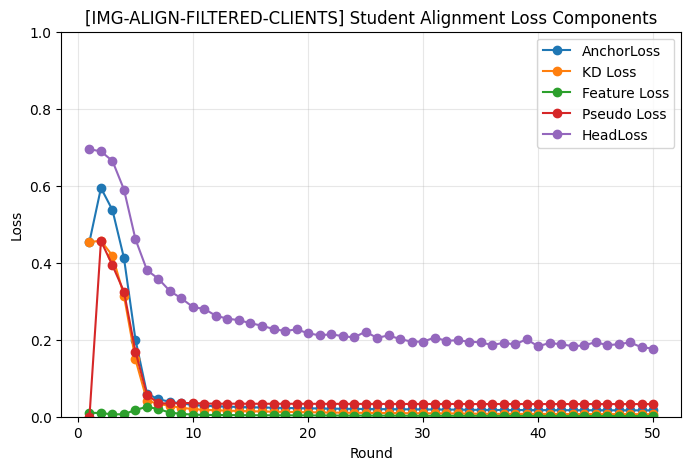

In [45]:
df = df_img_stage1.copy()

x_col = "round" if "round" in df.columns else None
x = df[x_col].values if x_col is not None else np.arange(1, len(df) + 1)

loss_items = {
    "AnchorLoss": ["anchor_loss", "AnchorLoss"],
    "KD Loss": ["anchor_kd_loss", "KD_loss", "kd_loss"],
    "Feature Loss": ["anchor_feat_loss", "feat_loss", "feature_loss"],
    "Pseudo Loss": ["anchor_pseudo_loss", "pseudo_loss"],
    "HeadLoss": ["head_loss", "HeadLoss"],
}

plt.figure(figsize=(8, 5))

plotted = False

for label, candidates in loss_items.items():
    col = _find_col(df, candidates)
    if col is not None:
        plt.plot(
            x,
            df[col].values,
            marker="o",
            label=label
        )
        plotted = True

if not plotted:
    print("No valid Stage 1 loss components found.")
    print("Available columns:", df.columns.tolist())
else:
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title(f"[{RUN_NAME_STAGE1}] Student Alignment Loss Components")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

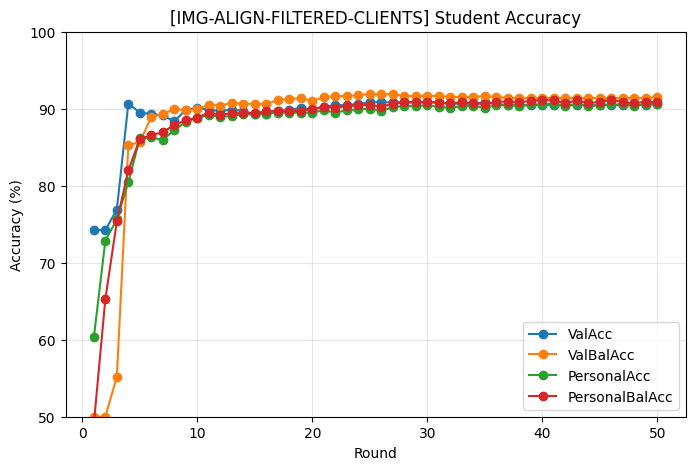

In [46]:
df = df_img_stage1.copy()

x_col = "round" if "round" in df.columns else None
x = df[x_col].values if x_col is not None else np.arange(1, len(df) + 1)

acc_items = {
    "ValAcc": ["val_acc", "ValAcc"],
    "ValBalAcc": ["val_bal_acc", "ValBalAcc"],
    "PersonalAcc": ["personal_acc", "PersonalAcc"],
    "PersonalBalAcc": ["personal_bal_acc", "PersonalBalAcc"],
}

plt.figure(figsize=(8, 5))

plotted = False

for label, candidates in acc_items.items():
    col = _find_col(df, candidates)
    if col is not None:
        plt.plot(
            x,
            df[col].values,
            marker="o",
            label=label
        )
        plotted = True

if not plotted:
    print("No valid Stage 1 accuracy metrics found.")
    print("Available columns:", df.columns.tolist())
else:
    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(f"[{RUN_NAME_STAGE1}] Student Accuracy")
    plt.ylim(50, 100)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [74]:
# Load all saved IMG Pneumonia Stage 1 & Stage 2 results

import torch
from pathlib import Path
import pandas as pd
import numpy as np

def torch_load_compat(path, map_location="cpu"):
    """
    Compatible torch.load for different PyTorch versions.
    Only use this for files saved by yourself.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


try:
    _map_location = device
except NameError:
    _map_location = "cpu"


def load_result(filename, map_location=_map_location):
    p = Path(filename)
    if not p.exists():
        raise FileNotFoundError(
            f"❌ Missing file: {filename}\n"
            f"Current directory: {Path.cwd()}"
        )

    print(f"✅ Loading {filename}")
    return torch_load_compat(str(p), map_location=map_location)


# =========================
# Stage 1 result
# =========================

result_img_align_filtered = load_result("IMG_PNEUMONIA_STAGE1_DEBUG.pt")
result_stage1 = result_img_align_filtered

RUN_NAME_STAGE1 = "IMG-PNEUMONIA-ALIGN-FILTERED"
RUN_NAME_STAGE2 = "IMG-PNEUMONIA-STAGE2"


# =========================
# Stage 2 results
# =========================

result_img_stage2_plain = load_result("IMG_PNEUMONIA_STAGE2_PLAIN_V1.pt")
result_img_stage2_plain_qw = load_result("IMG_PNEUMONIA_STAGE2_PLAIN_V2_QW.pt")
result_img_stage2_fhe_v1 = load_result("IMG_PNEUMONIA_STAGE2_FHE_V1.pt")
result_img_stage2_fhe_v2_qw = load_result("IMG_PNEUMONIA_STAGE2_FHE_V2_QW.pt")


# =========================
# Pack Stage 2 results into dictionary
# =========================

results_stage2 = {
    "Plain-v1": result_img_stage2_plain,
    "Plain-v2-QW": result_img_stage2_plain_qw,
    "FHE-v1": result_img_stage2_fhe_v1,
    "FHE-v2-QW": result_img_stage2_fhe_v2_qw,
}


# =========================
# Quick check
# =========================

print("\n" + "=" * 80)
print("✅ All IMG Pneumonia Stage 1 & Stage 2 results loaded.")
print("=" * 80)

print("\n[Stage 1] final_test_metrics:")
print(result_stage1.get("final_test_metrics", "No final_test_metrics found."))

print("\n[Stage 2] loaded methods:")
for name, result in results_stage2.items():
    print(f"\n{name}")
    print("best_round =", result.get("best_round", "N/A"))
    print("final_test_metrics =", result.get("final_test_metrics", "N/A"))

✅ Loading IMG_PNEUMONIA_STAGE1_DEBUG.pt
✅ Loading IMG_PNEUMONIA_STAGE2_PLAIN_V1.pt
✅ Loading IMG_PNEUMONIA_STAGE2_PLAIN_V2_QW.pt
✅ Loading IMG_PNEUMONIA_STAGE2_FHE_V1.pt
✅ Loading IMG_PNEUMONIA_STAGE2_FHE_V2_QW.pt

✅ All IMG Pneumonia Stage 1 & Stage 2 results loaded.

[Stage 1] final_test_metrics:
{'loss': 0.35071225273303497, 'acc': 87.17948717948718, 'bal_acc': 86.23931623931624, 'f1': 89.769820971867, 'recall': 90.0, 'precision': 89.54081632653062, 'specificity': 82.47863247863248, 'auprc': 93.13928646856893, 'pred_pos_rate': 62.82051282051282, 'true_pos_rate': 62.5, 'tn': 193, 'fp': 41, 'fn': 39, 'tp': 351}

[Stage 2] loaded methods:

Plain-v1
best_round = 47
final_test_metrics = {'loss': 0.3629304361649049, 'acc': 85.09615384615384, 'bal_acc': 82.6068376068376, 'f1': 88.58895705521472, 'recall': 92.56410256410257, 'precision': 84.94117647058823, 'specificity': 72.64957264957265, 'auprc': 92.15913927368334, 'pred_pos_rate': 68.10897435897436, 'true_pos_rate': 62.5, 'tn': 170, 'fp'

In [34]:
# Stage 2 Utilities
# Shared-personal decoupled FL

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


def _to_cpu_state_dict(sd):
    return {
        k: v.detach().cpu().clone()
        for k, v in sd.items()
    }


def get_backbone_state(model):
    return _to_cpu_state_dict(model.backbone.state_dict())


def load_backbone_state(model, backbone_sd, device):
    model.backbone.load_state_dict({
        k: v.to(device)
        for k, v in backbone_sd.items()
    })


def compute_backbone_delta(local_backbone_sd, global_backbone_sd):
    delta = {}
    for k in global_backbone_sd.keys():
        delta[k] = local_backbone_sd[k].cpu() - global_backbone_sd[k].cpu()
    return delta


def average_backbone_deltas(local_deltas, weights=None):
    if len(local_deltas) == 0:
        raise ValueError("No local deltas to average.")

    n = len(local_deltas)

    if weights is None:
        weights = np.ones(n, dtype=np.float64) / n
    else:
        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / max(weights.sum(), 1e-12)

    avg_delta = {}

    for k in local_deltas[0].keys():
        avg_delta[k] = torch.zeros_like(local_deltas[0][k])

        for i in range(n):
            avg_delta[k] += float(weights[i]) * local_deltas[i][k]

    return avg_delta


def apply_backbone_delta(global_backbone_sd, avg_delta):
    new_sd = {}

    for k in global_backbone_sd.keys():
        new_sd[k] = global_backbone_sd[k].cpu() + avg_delta[k].cpu()

    return new_sd

In [35]:
# Build Stage 2 models from Stage 1

def build_stage2_global_model(stage1_result, num_classes=2, device="cpu"):
    global_model = StudentModelECG1D(num_classes=num_classes).to(device)

    # Prefer full student state if available
    if "best_student_sd" in stage1_result and stage1_result["best_student_sd"] is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in stage1_result["best_student_sd"].items()
        })
    elif "student_model" in stage1_result and stage1_result["student_model"] is not None:
        global_model.load_state_dict(
            copy.deepcopy(stage1_result["student_model"].state_dict())
        )
    elif "best_shared_sd" in stage1_result and stage1_result["best_shared_sd"] is not None:
        global_model.backbone.load_state_dict({
            k: v.to(device)
            for k, v in stage1_result["best_shared_sd"].items()
        })
    else:
        raise ValueError("Cannot find Stage 1 student/backbone state.")

    return global_model


def build_stage2_client_models(
    stage1_result,
    num_clients,
    num_classes=2,
    device="cpu"
):
    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device
    )

    client_models = []

    for cid in range(num_clients):
        model = StudentModelECG1D(num_classes=num_classes).to(device)
        model.load_state_dict(copy.deepcopy(global_model.state_dict()))

        # Load Stage 1 personalized head if available
        if (
            "best_personal_heads" in stage1_result
            and stage1_result["best_personal_heads"] is not None
            and cid < len(stage1_result["best_personal_heads"])
        ):
            model.head.load_state_dict({
                k: v.to(device)
                for k, v in stage1_result["best_personal_heads"][cid].items()
            })

        client_models.append(model)

    return global_model, client_models

In [36]:
# Stage 2 Local Training / Evaluation

def local_stage2_train(
    model,
    train_loader,
    val_loader,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    grad_clip=10.0,
):
    model.to(device)
    model.train()

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    losses = []

    for _ in range(local_epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = F.cross_entropy(logits, yb, weight=ce_weight)

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            losses.append(loss.item())

    train_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan

    val_metrics = eval_model_binary(
        model=model,
        loader=val_loader,
        device=device,
        threshold=0.5
    )

    return {
        "train_loss": train_loss,
        "val_metrics": val_metrics,
    }


@torch.no_grad()
def eval_stage2_personal_models(client_models, client_val_loaders, device):
    y_true_all = []
    y_prob_all = []
    losses = []

    for cid, model in enumerate(client_models):
        model.eval()
        loader = client_val_loaders[cid]

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            prob = torch.softmax(logits, dim=1)[:, 1]

            losses.append(loss.item() * yb.size(0))
            y_true_all.extend(yb.detach().cpu().numpy().tolist())
            y_prob_all.extend(prob.detach().cpu().numpy().tolist())

    y_true = np.asarray(y_true_all)
    y_prob = np.asarray(y_prob_all)

    y_pred = (y_prob >= 0.5).astype(int)

    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        f1_score,
        recall_score,
        average_precision_score,
    )

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    auprc = average_precision_score(y_true, y_prob) * 100

    avg_loss = np.sum(losses) / max(len(y_true), 1)

    return {
        "loss": float(avg_loss),
        "acc": float(acc),
        "bal_acc": float(bal_acc),
        "f1": float(f1),
        "recall": float(recall),
        "auprc": float(auprc),
    }

In [37]:
# Quality-aware dynamic aggregation weights
# sample size + local validation performance

def compute_quality_weights(
    client_sample_sizes,
    client_val_metrics,
    sample_weight=0.5,
    quality_weight=0.5,
):
    sample_sizes = np.asarray(client_sample_sizes, dtype=np.float64)
    sample_norm = sample_sizes / max(sample_sizes.sum(), 1e-12)

    quality_scores = []

    for m in client_val_metrics:
        # Both are percentages
        q = 0.7 * m["bal_acc"] + 0.3 * m["auprc"]
        quality_scores.append(q)

    quality_scores = np.asarray(quality_scores, dtype=np.float64)

    # Avoid zero or negative weights
    quality_scores = np.maximum(quality_scores, 1e-6)
    quality_norm = quality_scores / max(quality_scores.sum(), 1e-12)

    weights = sample_weight * sample_norm + quality_weight * quality_norm
    weights = weights / max(weights.sum(), 1e-12)

    return weights

In [38]:
# Stage 2 Plain / Plain-QW Training

def stage2_train_plain(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=10,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
    use_quality_weights=False,
    run_name="CDC-STAGE2-PLAIN",
):
    print("=" * 80)
    print(f"[{run_name}] Stage 2 training start")
    print("=" * 80)

    num_clients = len(client_loaders)

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=num_clients,
        num_classes=num_classes,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    history = []

    best_score = -np.inf
    best_global_sd = None
    best_client_sds = None
    best_round = None

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_train_losses = []
        local_val_metrics = []
        client_sample_sizes = []

        # Local update
        for cid in range(num_clients):
            # Sync shared backbone before local training
            load_backbone_state(client_models[cid], global_backbone, device)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                val_loader=client_val_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
                grad_clip=10.0
            )

            local_train_losses.append(out["train_loss"])
            local_val_metrics.append(out["val_metrics"])

            client_sample_sizes.append(len(client_loaders[cid].dataset))

            local_backbone = get_backbone_state(client_models[cid])
            delta = compute_backbone_delta(local_backbone, global_backbone)
            local_deltas.append(delta)

        # Aggregation weights
        if use_quality_weights:
            weights = compute_quality_weights(
                client_sample_sizes=client_sample_sizes,
                client_val_metrics=local_val_metrics,
                sample_weight=0.5,
                quality_weight=0.5
            )
        else:
            weights = np.ones(num_clients, dtype=np.float64) / num_clients

        avg_delta = average_backbone_deltas(
            local_deltas=local_deltas,
            weights=weights
        )

        global_backbone = apply_backbone_delta(
            global_backbone_sd=global_backbone,
            avg_delta=avg_delta
        )

        # Sync global and client backbones after aggregation
        load_backbone_state(global_model, global_backbone, device)

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

        # Evaluation
        global_val_metrics = eval_model_binary(
            model=global_model,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_stage2_personal_models(
            client_models=client_models,
            client_val_loaders=client_val_loaders,
            device=device
        )

        mean_local_train_loss = float(np.nanmean(local_train_losses))

        row = {
            "round": rnd,
            "train_loss": mean_local_train_loss,

            "val_loss": global_val_metrics["loss"],
            "val_acc": global_val_metrics["acc"],
            "val_bal_acc": global_val_metrics["bal_acc"],
            "val_f1": global_val_metrics["f1"],
            "val_recall": global_val_metrics["recall"],
            "val_auprc": global_val_metrics["auprc"],

            "personal_loss": personal_metrics["loss"],
            "personal_acc": personal_metrics["acc"],
            "personal_bal_acc": personal_metrics["bal_acc"],
            "personal_f1": personal_metrics["f1"],
            "personal_recall": personal_metrics["recall"],
            "personal_auprc": personal_metrics["auprc"],

            "weights": weights.tolist(),
        }

        history.append(row)

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"TrainLoss={mean_local_train_loss:.4f} | "
            f"ValAcc={global_val_metrics['acc']:.2f}% | "
            f"ValBalAcc={global_val_metrics['bal_acc']:.2f}% | "
            f"ValF1={global_val_metrics['f1']:.2f}% | "
            f"ValAUPRC={global_val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

        # Best model selection
        score = (
            0.45 * global_val_metrics["bal_acc"]
            + 0.25 * global_val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if score > best_score:
            best_score = score
            best_round = rnd

            best_global_sd = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

            best_client_sds = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in client_models[cid].state_dict().items()
                }
                for cid in range(num_clients)
            ]

    # Restore best states
    if best_global_sd is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in best_global_sd.items()
        })

    if best_client_sds is not None:
        for cid in range(num_clients):
            client_models[cid].load_state_dict({
                k: v.to(device)
                for k, v in best_client_sds[cid].items()
            })

    final_test_metrics = eval_model_binary(
        model=global_model,
        loader=global_test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 2 completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final global test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "global_model": global_model,
        "client_models": client_models,
        "history": history,
        "best_round": best_round,
        "best_score": best_score,
        "best_global_sd": best_global_sd,
        "best_client_sds": best_client_sds,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
        "use_quality_weights": use_quality_weights,
    }

    return result

In [39]:
result_img_stage2_plain = stage2_train_plain(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=False,
    run_name="IMG-PNEUMONIA-STAGE2-PLAIN-V1"
)

torch.save(result_img_stage2_plain, "IMG_PNEUMONIA_STAGE2_PLAIN_V1.pt")
print("Saved IMG_PNEUMONIA_STAGE2_PLAIN_V1.pt")

[IMG-PNEUMONIA-STAGE2-PLAIN-V1] Stage 2 training start

[IMG-PNEUMONIA-STAGE2-PLAIN-V1] Round 1/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V1][Round 1/50] TrainLoss=0.2624 | ValAcc=87.98% | ValBalAcc=90.45% | ValF1=91.33% | ValAUPRC=99.10% | PersonalAcc=88.52% | PersonalBalAcc=90.35% | PersonalF1=91.88%

[IMG-PNEUMONIA-STAGE2-PLAIN-V1] Round 2/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V1][Round 2/50] TrainLoss=0.2597 | ValAcc=90.84% | ValBalAcc=91.65% | ValF1=93.58% | ValAUPRC=99.10% | PersonalAcc=90.77% | PersonalBalAcc=90.71% | PersonalF1=93.65%

[IMG-PNEUMONIA-STAGE2-PLAIN-V1] Round 3/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V1][Round 3/50] TrainLoss=0.2687 | ValAcc=90.84% | ValBalAcc=91.65% | ValF1=93.58% | ValAUPRC=99.11% | PersonalAcc=91.09% | PersonalBalAcc=90.65% | PersonalF1=93.90%

[IMG-PNEUMONIA-STAGE2-PLAIN-V1] Round 4/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V1][Round 4/50] TrainLoss=0.2638 | ValAcc=87.79% | ValBalAcc=90.32% | ValF1=91.18% | ValAUPRC=99.14% | PersonalAcc=89.06% | PersonalBalAcc=90.56% | PersonalF1=

In [40]:
result_img_stage2_plain_qw = stage2_train_plain(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=True,
    run_name="IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW"
)

torch.save(result_img_stage2_plain_qw, "IMG_PNEUMONIA_STAGE2_PLAIN_V2_QW.pt")
print("Saved IMG_PNEUMONIA_STAGE2_PLAIN_V2_QW.pt")

[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW] Stage 2 training start

[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW] Round 1/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW][Round 1/50] TrainLoss=0.2692 | ValAcc=89.12% | ValBalAcc=90.74% | ValF1=92.27% | ValAUPRC=99.10% | PersonalAcc=89.27% | PersonalBalAcc=90.42% | PersonalF1=92.48%

[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW] Round 2/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW][Round 2/50] TrainLoss=0.2799 | ValAcc=91.03% | ValBalAcc=92.02% | ValF1=93.71% | ValAUPRC=99.11% | PersonalAcc=90.45% | PersonalBalAcc=90.93% | PersonalF1=93.38%

[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW] Round 3/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW][Round 3/50] TrainLoss=0.2631 | ValAcc=88.36% | ValBalAcc=90.71% | ValF1=91.63% | ValAUPRC=99.14% | PersonalAcc=88.73% | PersonalBalAcc=90.49% | PersonalF1=92.04%

[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW] Round 4/50
[IMG-PNEUMONIA-STAGE2-PLAIN-V2-QW][Round 4/50] TrainLoss=0.2619 | ValAcc=89.50% | ValBalAcc=91.00% | ValF1=92.56% | ValAUPRC=99.15% | PersonalAcc=89.91% | Personal

In [41]:
try:
    import tenseal as ts
    print("TenSEAL imported successfully.")
except ImportError:
    raise ImportError(
        "TenSEAL is not installed. Please install it first, e.g. pip install tenseal"
    )

TenSEAL imported successfully.


In [42]:
# FHE Backend: CKKS via TenSEAL

class CKKSBackend:
    def __init__(
        self,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60],
        global_scale=2**40,
        chunk_size=2048,
    ):
        self.poly_modulus_degree = poly_modulus_degree
        self.coeff_mod_bit_sizes = coeff_mod_bit_sizes
        self.global_scale = global_scale
        self.chunk_size = chunk_size

        self.context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=poly_modulus_degree,
            coeff_mod_bit_sizes=coeff_mod_bit_sizes,
        )
        self.context.global_scale = global_scale
        self.context.generate_galois_keys()

    def encrypt_vector(self, x):
        return ts.ckks_vector(self.context, x)

    def decrypt_vector(self, enc_x):
        return enc_x.decrypt()

In [43]:
he_backend = CKKSBackend(
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60],
    global_scale=2**40,
    chunk_size=2048,
)

print("CKKS backend ready.")

CKKS backend ready.


In [44]:
# Flatten / unflatten backbone state dict

def flatten_state_dict(sd):
    keys = []
    shapes = []
    arrays = []

    for k, v in sd.items():
        arr = v.detach().cpu().numpy().reshape(-1).astype(np.float64)
        keys.append(k)
        shapes.append(tuple(v.shape))
        arrays.append(arr)

    flat = np.concatenate(arrays, axis=0)
    return flat, keys, shapes


def unflatten_to_state_dict(flat, keys, shapes, reference_sd):
    new_sd = {}
    offset = 0

    for k, shape in zip(keys, shapes):
        size = int(np.prod(shape))
        part = flat[offset: offset + size].reshape(shape)
        offset += size

        dtype = reference_sd[k].dtype
        new_sd[k] = torch.tensor(part, dtype=dtype)

    return new_sd


def chunk_vector(x, chunk_size):
    return [
        x[i:i + chunk_size]
        for i in range(0, len(x), chunk_size)
    ]

In [45]:
# FHE encrypted averaging of backbone deltas

import time

def he_average_backbone_deltas(
    local_deltas,
    he_backend,
    weights=None,
    device="cpu",
):
    if len(local_deltas) == 0:
        raise ValueError("No local deltas to aggregate.")

    n = len(local_deltas)

    if weights is None:
        weights = np.ones(n, dtype=np.float64) / n
    else:
        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / max(weights.sum(), 1e-12)

    # Use first delta as reference
    ref_delta = local_deltas[0]
    flat0, keys, shapes = flatten_state_dict(ref_delta)
    numel = len(flat0)

    flat_deltas = []
    for delta in local_deltas:
        flat, _, _ = flatten_state_dict(delta)
        flat_deltas.append(flat)

    chunk_size = he_backend.chunk_size
    num_chunks = int(np.ceil(numel / chunk_size))

    enc_start = time.time()

    encrypted_chunks_all = []

    for i in range(n):
        chunks = chunk_vector(flat_deltas[i], chunk_size)
        enc_chunks = [
            he_backend.encrypt_vector(chunk.tolist())
            for chunk in chunks
        ]
        encrypted_chunks_all.append(enc_chunks)

    enc_time = time.time() - enc_start

    agg_start = time.time()

    agg_enc_chunks = []

    for cidx in range(num_chunks):
        agg_chunk = encrypted_chunks_all[0][cidx] * float(weights[0])

        for i in range(1, n):
            agg_chunk += encrypted_chunks_all[i][cidx] * float(weights[i])

        agg_enc_chunks.append(agg_chunk)

    agg_time = time.time() - agg_start

    dec_start = time.time()

    decrypted_chunks = [
        np.array(chunk.decrypt(), dtype=np.float64)
        for chunk in agg_enc_chunks
    ]

    avg_flat = np.concatenate(decrypted_chunks, axis=0)[:numel]

    dec_time = time.time() - dec_start

    avg_delta = unflatten_to_state_dict(
        flat=avg_flat,
        keys=keys,
        shapes=shapes,
        reference_sd=ref_delta,
    )

    he_stats = {
    "num_clients": int(len(local_deltas)),
    "numel": int(numel),
    "num_chunks": int(num_chunks),
    "encrypt_time_sec": float(enc_time),
    "aggregate_time_sec": float(agg_time),
    "decrypt_time_sec": float(dec_time),
    "upload_ciphertexts_per_round": int(len(local_deltas) * num_chunks),
    "aggregated_ciphertexts_per_round": int(num_chunks),
    }

    print(
        f"HE(numel={numel}, chunks={num_chunks}, "
        f"enc={enc_time:.6f}s, agg={agg_time:.6f}s, dec={dec_time:.6f}s)"
)
    return avg_delta, he_stats

In [46]:
def stage2_train_fhe(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    he_backend,
    num_rounds=10,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
    use_quality_weights=False,
    run_name="CDC-STAGE2-FHE-V1",
):
    print("=" * 80)
    print(f"[{run_name}] Stage 2 FHE training start")
    print("=" * 80)

    num_clients = len(client_loaders)

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=num_clients,
        num_classes=num_classes,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    history = []

    best_score = -np.inf
    best_global_sd = None
    best_client_sds = None
    best_round = None

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_train_losses = []
        local_val_metrics = []
        client_sample_sizes = []

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                val_loader=client_val_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
                grad_clip=10.0
            )

            local_train_losses.append(out["train_loss"])
            local_val_metrics.append(out["val_metrics"])
            client_sample_sizes.append(len(client_loaders[cid].dataset))

            local_backbone = get_backbone_state(client_models[cid])
            delta = compute_backbone_delta(local_backbone, global_backbone)
            local_deltas.append(delta)

        if use_quality_weights:
            weights = compute_quality_weights(
                client_sample_sizes=client_sample_sizes,
                client_val_metrics=local_val_metrics,
                sample_weight=0.5,
                quality_weight=0.5
            )
        else:
            weights = np.ones(num_clients, dtype=np.float64) / num_clients

        # FHE encrypted aggregation
        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,
            device=device
        )

        global_backbone = apply_backbone_delta(
            global_backbone_sd=global_backbone,
            avg_delta=avg_delta
        )

        load_backbone_state(global_model, global_backbone, device)

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

        global_val_metrics = eval_model_binary(
            model=global_model,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_stage2_personal_models(
            client_models=client_models,
            client_val_loaders=client_val_loaders,
            device=device
        )

        mean_local_train_loss = float(np.nanmean(local_train_losses))

        row = {
            "round": rnd,
            "train_loss": mean_local_train_loss,

            "val_loss": global_val_metrics["loss"],
            "val_acc": global_val_metrics["acc"],
            "val_bal_acc": global_val_metrics["bal_acc"],
            "val_f1": global_val_metrics["f1"],
            "val_recall": global_val_metrics["recall"],
            "val_auprc": global_val_metrics["auprc"],

            "personal_loss": personal_metrics["loss"],
            "personal_acc": personal_metrics["acc"],
            "personal_bal_acc": personal_metrics["bal_acc"],
            "personal_f1": personal_metrics["f1"],
            "personal_recall": personal_metrics["recall"],
            "personal_auprc": personal_metrics["auprc"],
            # HE overhead statistics
            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],
            
            # Communication proxy
            "he_upload_ciphertexts_per_round": he_stats["upload_ciphertexts_per_round"],
            "he_aggregated_ciphertexts_per_round": he_stats["aggregated_ciphertexts_per_round"],

            "weights": weights.tolist(),
        }

        history.append(row)

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"TrainLoss={mean_local_train_loss:.4f} | "
            f"ValAcc={global_val_metrics['acc']:.2f}% | "
            f"ValBalAcc={global_val_metrics['bal_acc']:.2f}% | "
            f"ValF1={global_val_metrics['f1']:.2f}% | "
            f"ValAUPRC={global_val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

        score = (
            0.45 * global_val_metrics["bal_acc"]
            + 0.25 * global_val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if score > best_score:
            best_score = score
            best_round = rnd

            best_global_sd = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

            best_client_sds = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in client_models[cid].state_dict().items()
                }
                for cid in range(num_clients)
            ]

    if best_global_sd is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in best_global_sd.items()
        })

    if best_client_sds is not None:
        for cid in range(num_clients):
            client_models[cid].load_state_dict({
                k: v.to(device)
                for k, v in best_client_sds[cid].items()
            })

    final_test_metrics = eval_model_binary(
        model=global_model,
        loader=global_test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 2 FHE completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final global test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "global_model": global_model,
        "client_models": client_models,
        "history": history,
        "best_round": best_round,
        "best_score": best_score,
        "best_global_sd": best_global_sd,
        "best_client_sds": best_client_sds,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
        "use_quality_weights": use_quality_weights,
        "he_config": {
            "poly_modulus_degree": he_backend.poly_modulus_degree,
            "coeff_mod_bit_sizes": he_backend.coeff_mod_bit_sizes,
            "global_scale": he_backend.global_scale,
            "chunk_size": he_backend.chunk_size,
        }
    }

    return result

In [83]:
FORCE_RETRAIN = True
result_img_stage2_fhe_v1 = stage2_train_fhe(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,
    he_backend=he_backend,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=False,
    run_name="IMG-PNEUMONIA-STAGE2-FHE-V1"
)

torch.save(result_img_stage2_fhe_v1, "IMG_PNEUMONIA_STAGE2_FHE_V1_WITH_TIME.pt")
print("Saved IMG_PNEUMONIA_STAGE2_FHE_V1_WITH_TIME.pt")

[IMG-PNEUMONIA-STAGE2-FHE-V1] Stage 2 FHE training start

[IMG-PNEUMONIA-STAGE2-FHE-V1] Round 1/50
HE(numel=25816, chunks=13, enc=0.239322s, agg=0.041598s, dec=0.010241s)
[IMG-PNEUMONIA-STAGE2-FHE-V1][Round 1/50] TrainLoss=0.2721 | ValAcc=90.84% | ValBalAcc=91.65% | ValF1=93.58% | ValAUPRC=99.08% | PersonalAcc=90.45% | PersonalBalAcc=90.93% | PersonalF1=93.38%

[IMG-PNEUMONIA-STAGE2-FHE-V1] Round 2/50
HE(numel=25816, chunks=13, enc=0.224960s, agg=0.038886s, dec=0.009985s)
[IMG-PNEUMONIA-STAGE2-FHE-V1][Round 2/50] TrainLoss=0.2615 | ValAcc=91.22% | ValBalAcc=91.43% | ValF1=93.90% | ValAUPRC=99.09% | PersonalAcc=91.52% | PersonalBalAcc=90.93% | PersonalF1=94.21%

[IMG-PNEUMONIA-STAGE2-FHE-V1] Round 3/50
HE(numel=25816, chunks=13, enc=0.228226s, agg=0.038620s, dec=0.009892s)
[IMG-PNEUMONIA-STAGE2-FHE-V1][Round 3/50] TrainLoss=0.2593 | ValAcc=89.31% | ValBalAcc=91.11% | ValF1=92.39% | ValAUPRC=99.10% | PersonalAcc=89.38% | PersonalBalAcc=90.64% | PersonalF1=92.55%

[IMG-PNEUMONIA-STAGE2-FH

In [84]:
FORCE_RETRAIN = True
result_img_stage2_fhe_v2_qw = stage2_train_fhe(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,
    he_backend=he_backend,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=True,
    run_name="IMG-PNEUMONIA-STAGE2-FHE-V2-QW"
)

torch.save(result_img_stage2_fhe_v2_qw, "IMG_PNEUMONIA_STAGE2_FHE_V2_QW_WITH_TIME.pt")
print("Saved IMG_PNEUMONIA_STAGE2_FHE_V2_QW_WITH_TIME.pt")

[IMG-PNEUMONIA-STAGE2-FHE-V2-QW] Stage 2 FHE training start

[IMG-PNEUMONIA-STAGE2-FHE-V2-QW] Round 1/50
HE(numel=25816, chunks=13, enc=0.225634s, agg=0.038767s, dec=0.010027s)
[IMG-PNEUMONIA-STAGE2-FHE-V2-QW][Round 1/50] TrainLoss=0.2603 | ValAcc=88.74% | ValBalAcc=90.97% | ValF1=91.93% | ValAUPRC=99.11% | PersonalAcc=88.84% | PersonalBalAcc=90.42% | PersonalF1=92.13%

[IMG-PNEUMONIA-STAGE2-FHE-V2-QW] Round 2/50
HE(numel=25816, chunks=13, enc=0.229133s, agg=0.038627s, dec=0.010000s)
[IMG-PNEUMONIA-STAGE2-FHE-V2-QW][Round 2/50] TrainLoss=0.2736 | ValAcc=91.03% | ValBalAcc=91.30% | ValF1=93.76% | ValAUPRC=99.11% | PersonalAcc=91.42% | PersonalBalAcc=90.86% | PersonalF1=94.13%

[IMG-PNEUMONIA-STAGE2-FHE-V2-QW] Round 3/50
HE(numel=25816, chunks=13, enc=0.228875s, agg=0.038685s, dec=0.009986s)
[IMG-PNEUMONIA-STAGE2-FHE-V2-QW][Round 3/50] TrainLoss=0.2627 | ValAcc=91.03% | ValBalAcc=92.02% | ValF1=93.71% | ValAUPRC=99.13% | PersonalAcc=90.99% | PersonalBalAcc=91.14% | PersonalF1=93.79%

[IM

In [85]:
def extract_final_metrics(result, name):
    m = result["final_test_metrics"]
    return {
        "Setting": name,
        "Acc": m["acc"],
        "BalAcc": m["bal_acc"],
        "F1": m["f1"],
        "Recall": m["recall"],
        "Precision": m["precision"],
        "Specificity": m["specificity"],
        "AUPRC": m["auprc"],
        "PredPosRate": m["pred_pos_rate"],
    }

compare_all_stage2_df = pd.DataFrame([
    extract_final_metrics(result_img_stage2_plain, "Stage2-Plain-v1"),
    extract_final_metrics(result_img_stage2_plain_qw, "Stage2-Plain-v2-QW"),
    extract_final_metrics(result_img_stage2_fhe_v1, "Stage2-FHE-v1"),
    extract_final_metrics(result_img_stage2_fhe_v2_qw, "Stage2-FHE-v2-QW"),
])

compare_all_stage2_df

compare_all_stage2_df.to_csv("IMG_STAGE2_FINAL_COMPARISON.csv", index=False)
print("Saved IMG_STAGE2_FINAL_COMPARISON.csv")

Saved IMG_STAGE2_FINAL_COMPARISON.csv


In [86]:
# Lock Stage 2 results
results_stage2 = {
    "Plain-v1": result_img_stage2_plain,
    "Plain-v2-QW": result_img_stage2_plain_qw,
    "FHE-v1": result_img_stage2_fhe_v1,
    "FHE-v2-QW": result_img_stage2_fhe_v2_qw,
}

for name, result in results_stage2.items():
    print(name, "best_round =", result["best_round"])
    print(result["final_test_metrics"])
    print()

Plain-v1 best_round = 47
{'loss': 0.3629304361649049, 'acc': 85.09615384615384, 'bal_acc': 82.6068376068376, 'f1': 88.58895705521472, 'recall': 92.56410256410257, 'precision': 84.94117647058823, 'specificity': 72.64957264957265, 'auprc': 92.15913927368334, 'pred_pos_rate': 68.10897435897436, 'true_pos_rate': 62.5, 'tn': 170, 'fp': 64, 'fn': 29, 'tp': 361}

Plain-v2-QW best_round = 37
{'loss': 0.35950958805206495, 'acc': 85.25641025641025, 'bal_acc': 82.82051282051282, 'f1': 88.6977886977887, 'recall': 92.56410256410257, 'precision': 85.14150943396226, 'specificity': 73.07692307692307, 'auprc': 92.28898174752325, 'pred_pos_rate': 67.94871794871796, 'true_pos_rate': 62.5, 'tn': 171, 'fp': 63, 'fn': 29, 'tp': 361}

FHE-v1 best_round = 46
{'loss': 0.3609695977125412, 'acc': 85.41666666666666, 'bal_acc': 82.94871794871794, 'f1': 88.83435582822085, 'recall': 92.82051282051282, 'precision': 85.1764705882353, 'specificity': 73.07692307692307, 'auprc': 92.33277870397714, 'pred_pos_rate': 68.108

In [41]:
# IMG Pneumonia CKKS vs Paillier Communication Micro-benchmark
# Same update parameters, real encryption

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from phe import paillier
    print("✅ phe imported")
except Exception:
    import sys
    import subprocess
    print("Installing phe ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "phe"])
    from phe import paillier
    print("✅ phe imported after installation")


def get_img_real_backbone_delta_vector(stage1_result, device="cpu"):
    """
    从 IMG Stage 2 中抽取一个真实 backbone delta。
    不是随机向量，而是用第一个 good client 训练 1 epoch 后得到的真实模型更新。
    """

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders_good),
        num_classes=NUM_CLASSES,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    cid = 0
    load_backbone_state(client_models[cid], global_backbone, device)

    out = local_stage2_train(
        model=client_models[cid],
        train_loader=client_loaders_good[cid],
        val_loader=client_val_loaders_good[cid],
        local_epochs=1,
        lr=5e-4,
        device=device,
        class_weights=class_weights,
        grad_clip=10.0
    )

    local_backbone = get_backbone_state(client_models[cid])
    delta = compute_backbone_delta(local_backbone, global_backbone)

    flat_delta, keys, shapes = flatten_state_dict(delta)
    flat_delta = flat_delta.astype(np.float64)

    print(f"✅ IMG real backbone delta extracted | numel={flat_delta.size}")

    return flat_delta


def benchmark_img_ckks_encrypt_vector(
    x,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60],
    global_scale=2**40,
    chunk_size=2048,
):
    """
    真实 CKKS 加密通信统计。
    使用当前 IMG notebook 里的 CKKSBackend。
    """

    backend = CKKSBackend(
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bit_sizes,
        global_scale=global_scale,
        chunk_size=chunk_size,
    )

    chunks = chunk_vector(np.asarray(x, dtype=np.float64), chunk_size)

    enc_chunks = []
    ciphertext_bytes = 0

    t0 = time.time()

    for chunk in chunks:
        enc = backend.encrypt_vector(chunk.tolist())
        enc_chunks.append(enc)

        try:
            ciphertext_bytes += len(enc.serialize())
        except Exception:
            ciphertext_bytes += np.nan

    enc_time = time.time() - t0

    num_ciphertexts = len(enc_chunks)

    return {
        "scheme": "CKKS",
        "num_params": len(x),
        "num_ciphertexts": num_ciphertexts,
        "ciphertext_bytes": float(ciphertext_bytes),
        "ciphertext_mb": float(ciphertext_bytes / (1024 ** 2)),
        "encrypt_time_sec": float(enc_time),
        "bytes_per_param": float(ciphertext_bytes / max(len(x), 1)),
    }


def benchmark_img_paillier_encrypt_vector(
    x,
    key_length=1024,
    scale=1e6,
):
    """
    真实 Paillier 加密通信统计。
    Paillier 是逐标量加密，所以 K 不要设置得过大。
    """

    public_key, private_key = paillier.generate_paillier_keypair(
        n_length=key_length
    )

    x_int = np.round(np.asarray(x, dtype=np.float64) * scale).astype(np.int64)

    ciphertext_bytes = 0
    enc_values = []

    t0 = time.time()

    for v in x_int:
        enc = public_key.encrypt(int(v))
        enc_values.append(enc)

        c = enc.ciphertext(be_secure=False)
        ciphertext_bytes += int((c.bit_length() + 7) // 8)

    enc_time = time.time() - t0

    return {
        "scheme": "Paillier",
        "num_params": len(x),
        "num_ciphertexts": len(x),
        "ciphertext_bytes": float(ciphertext_bytes),
        "ciphertext_mb": float(ciphertext_bytes / (1024 ** 2)),
        "encrypt_time_sec": float(enc_time),
        "bytes_per_param": float(ciphertext_bytes / max(len(x), 1)),
    }


def run_img_ckks_vs_paillier_micro_benchmark(
    flat_delta,
    k_list=None,
    paillier_key_length=1024,
    paillier_scale=1e6,
    ckks_chunk_size=2048,
):
    """
    对同一个真实 backbone delta 的前 K 个参数做 CKKS vs Paillier 对比。
    """

    if k_list is None:
        candidate_k = [256, 512, 1024, 2048, 4096, 8192]
        k_list = [k for k in candidate_k if k <= len(flat_delta)]

        if len(flat_delta) not in k_list:
            k_list.append(len(flat_delta))

    rows = []

    for k in k_list:
        x = flat_delta[:k]

        print(f"\nRunning IMG benchmark for K={k} parameters ...")

        ckks_row = benchmark_img_ckks_encrypt_vector(
            x,
            chunk_size=ckks_chunk_size,
        )
        rows.append(ckks_row)

        paillier_row = benchmark_img_paillier_encrypt_vector(
            x,
            key_length=paillier_key_length,
            scale=paillier_scale,
        )
        rows.append(paillier_row)

        print(
            f"K={k} | "
            f"CKKS={ckks_row['ciphertext_mb']:.4f}MB, "
            f"Paillier={paillier_row['ciphertext_mb']:.4f}MB | "
            f"CKKS time={ckks_row['encrypt_time_sec']:.6f}s, "
            f"Paillier time={paillier_row['encrypt_time_sec']:.6f}s"
        )

    df = pd.DataFrame(rows)

    df["plaintext_bytes_float32"] = df["num_params"] * 4
    df["expansion_ratio_vs_plain"] = (
        df["ciphertext_bytes"] / df["plaintext_bytes_float32"]
    )

    return df


# 1. 抽取一个 IMG 真实 Stage 2 backbone delta
img_flat_delta_for_benchmark = get_img_real_backbone_delta_vector(
    result_stage1,
    device=device,
)

# 2. 对相同参数做 CKKS vs Paillier 真实加密通信对比
img_encryption_comm_benchmark_df = run_img_ckks_vs_paillier_micro_benchmark(
    flat_delta=img_flat_delta_for_benchmark,
    k_list=[256, 512, 1024, 2048, 4096, 8192],
    paillier_key_length=1024,
    paillier_scale=1e6,
    ckks_chunk_size=2048,
)

display(img_encryption_comm_benchmark_df)

# 3. 保存结果，方便之后写论文/画图
img_encryption_comm_benchmark_df.to_csv(
    "IMG_CKKS_VS_PAILLIER_COMM_BENCHMARK.csv",
    index=False
)

print("Saved IMG_CKKS_VS_PAILLIER_COMM_BENCHMARK.csv")

✅ phe imported
✅ IMG real backbone delta extracted | numel=25816

Running IMG benchmark for K=256 parameters ...
K=256 | CKKS=0.3188MB, Paillier=0.0625MB | CKKS time=0.006773s, Paillier time=3.447762s

Running IMG benchmark for K=512 parameters ...
K=512 | CKKS=0.3189MB, Paillier=0.1250MB | CKKS time=0.003671s, Paillier time=6.845228s

Running IMG benchmark for K=1024 parameters ...
K=1024 | CKKS=0.3190MB, Paillier=0.2500MB | CKKS time=0.003599s, Paillier time=13.790572s

Running IMG benchmark for K=2048 parameters ...
K=2048 | CKKS=0.3188MB, Paillier=0.5000MB | CKKS time=0.004025s, Paillier time=27.354861s

Running IMG benchmark for K=4096 parameters ...
K=4096 | CKKS=0.6379MB, Paillier=1.0000MB | CKKS time=0.007440s, Paillier time=54.328693s

Running IMG benchmark for K=8192 parameters ...
K=8192 | CKKS=1.2735MB, Paillier=2.0000MB | CKKS time=0.011528s, Paillier time=114.540922s


,scheme,num_params,num_ciphertexts,ciphertext_bytes,ciphertext_mb,encrypt_time_sec,bytes_per_param,plaintext_bytes_float32,expansion_ratio_vs_plain
0,CKKS,256,1,334327.0,0.318839,0.006773,1305.964844,1024,326.491211
1,Paillier,256,256,65532.0,0.062496,3.447762,255.984375,1024,63.996094
2,CKKS,512,1,334368.0,0.318878,0.003671,653.062500,2048,163.265625
3,Paillier,512,512,131070.0,0.124998,6.845228,255.996094,2048,63.999023
4,CKKS,1024,1,334522.0,0.319025,0.003599,326.681641,4096,81.670410
5,Paillier,1024,1024,262132.0,0.249989,13.790572,255.988281,4096,63.997070
6,CKKS,2048,1,334268.0,0.318783,0.004025,163.216797,8192,40.804199
7,Paillier,2048,2048,524269.0,0.499982,27.354861,255.990723,8192,63.997681
8,CKKS,4096,2,668842.0,0.637857,0.007440,163.291504,16384,40.822876
9,Paillier,4096,4096,1048544.0,0.999969,54.328693,255.992188,16384,63.998047


Saved IMG_CKKS_VS_PAILLIER_COMM_BENCHMARK.csv


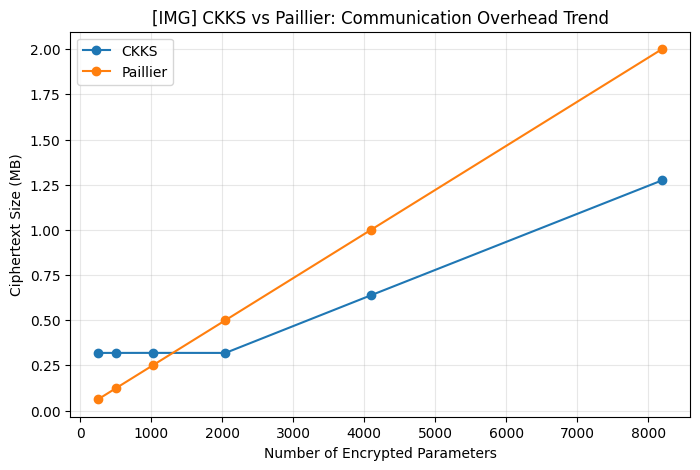

In [67]:
# Plot IMG CKKS vs Paillier Communication Trends

def plot_img_ckks_vs_paillier_trends(df):
    df = df.sort_values(["scheme", "num_params"]).copy()

    ckks_df = df[df["scheme"] == "CKKS"].sort_values("num_params")
    paillier_df = df[df["scheme"] == "Paillier"].sort_values("num_params")

    # 1. Communication overhead trend
    plt.figure(figsize=(8, 5))
    plt.plot(
        ckks_df["num_params"],
        ckks_df["ciphertext_mb"],
        marker="o",
        label="CKKS"
    )
    plt.plot(
        paillier_df["num_params"],
        paillier_df["ciphertext_mb"],
        marker="o",
        label="Paillier"
    )
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Ciphertext Size (MB)")
    plt.title("[IMG] CKKS vs Paillier: Communication Overhead Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
'''
    # 2. Expansion ratio trend
    plt.figure(figsize=(8, 5))
    plt.plot(
        ckks_df["num_params"],
        ckks_df["expansion_ratio_vs_plain"],
        marker="o",
        label="CKKS"
    )
    plt.plot(
        paillier_df["num_params"],
        paillier_df["expansion_ratio_vs_plain"],
        marker="o",
        label="Paillier"
    )
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Ciphertext / Plaintext Ratio")
    plt.title("[IMG] CKKS vs Paillier: Expansion Ratio Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 3. Encryption time trend
    plt.figure(figsize=(8, 5))
    plt.plot(
        ckks_df["num_params"],
        ckks_df["encrypt_time_sec"],
        marker="o",
        label="CKKS"
    )
    plt.plot(
        paillier_df["num_params"],
        paillier_df["encrypt_time_sec"],
        marker="o",
        label="Paillier"
    )
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Encryption Time (seconds)")
    plt.title("[IMG] CKKS vs Paillier: Encryption Time Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
'''

plot_img_ckks_vs_paillier_trends(img_encryption_comm_benchmark_df)

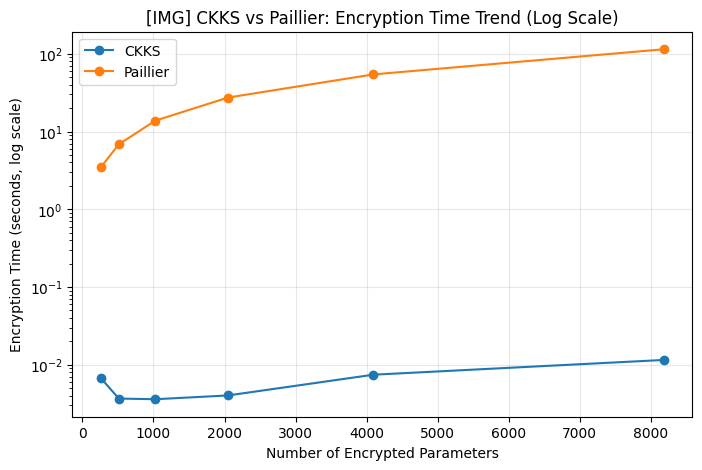

In [44]:
# Optional: IMG Encryption Time Trend - Log Scale

def plot_img_encryption_time_log(df):
    df = df.sort_values(["scheme", "num_params"]).copy()

    ckks_df = df[df["scheme"] == "CKKS"].sort_values("num_params")
    paillier_df = df[df["scheme"] == "Paillier"].sort_values("num_params")

    plt.figure(figsize=(8, 5))

    plt.plot(
        ckks_df["num_params"],
        ckks_df["encrypt_time_sec"],
        marker="o",
        label="CKKS"
    )

    plt.plot(
        paillier_df["num_params"],
        paillier_df["encrypt_time_sec"],
        marker="o",
        label="Paillier"
    )

    plt.yscale("log")
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Encryption Time (seconds, log scale)")
    plt.title("[IMG] CKKS vs Paillier: Encryption Time Trend (Log Scale)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_img_encryption_time_log(img_encryption_comm_benchmark_df)

In [57]:
print("FHE-v1 history columns:")
print(pd.DataFrame(result_img_stage2_fhe_v1["history"]).columns.tolist())

print("\nFHE-v2-QW history columns:")
print(pd.DataFrame(result_img_stage2_fhe_v2_qw["history"]).columns.tolist())

FHE-v1 history columns:
['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc', 'personal_bal_acc', 'personal_f1', 'personal_recall', 'personal_auprc', 'he_num_clients', 'he_numel', 'he_num_chunks', 'he_encrypt_time_sec', 'he_aggregate_time_sec', 'he_decrypt_time_sec', 'he_upload_ciphertexts_per_round', 'he_aggregated_ciphertexts_per_round', 'weights']

FHE-v2-QW history columns:
['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc', 'personal_bal_acc', 'personal_f1', 'personal_recall', 'personal_auprc', 'he_num_clients', 'he_numel', 'he_num_chunks', 'he_encrypt_time_sec', 'he_aggregate_time_sec', 'he_decrypt_time_sec', 'he_upload_ciphertexts_per_round', 'he_aggregated_ciphertexts_per_round', 'weights']


In [57]:
# PneumoniaMNIST Stage 2 - FHE-v1 vs FHE-v2-QW Overhead Overview

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def build_img_fhe_overview_df(result_dict):
    rows = []

    for method_name, result in result_dict.items():
        df = pd.DataFrame(result["history"]).copy()

        avg_enc = df["he_encrypt_time_sec"].mean()
        avg_agg = df["he_aggregate_time_sec"].mean()
        avg_dec = df["he_decrypt_time_sec"].mean()

        avg_total = (
            df["he_encrypt_time_sec"]
            + df["he_aggregate_time_sec"]
            + df["he_decrypt_time_sec"]
        ).mean()

        # communication proxy
        if "he_upload_ciphertexts_per_round" in df.columns:
            avg_upload_ciphertexts = df["he_upload_ciphertexts_per_round"].mean()
        else:
            avg_upload_ciphertexts = (
                df["he_num_clients"] * df["he_num_chunks"]
            ).mean()

        if "he_aggregated_ciphertexts_per_round" in df.columns:
            avg_aggregated_ciphertexts = df["he_aggregated_ciphertexts_per_round"].mean()
        else:
            avg_aggregated_ciphertexts = df["he_num_chunks"].mean()

        rows.append({
            "Method": method_name,
            "Rounds": len(df),

            "Avg Encrypt Time (s)": avg_enc,
            "Avg Aggregate Time (s)": avg_agg,
            "Avg Decrypt Time (s)": avg_dec,
            "Avg Total HE Time (s)": avg_total,

            "Avg Num Clients": df["he_num_clients"].mean(),
            "Avg Numel": df["he_numel"].mean(),
            "Avg Num Chunks": df["he_num_chunks"].mean(),

            "Avg Upload Ciphertexts / Round": avg_upload_ciphertexts,
            "Avg Aggregated Ciphertexts / Round": avg_aggregated_ciphertexts,
        })

    return pd.DataFrame(rows)


def plot_img_fhe_one_overview(
    summary_df,
    title="[PneumoniaMNIST Stage 2] FHE-v1 vs FHE-v2-QW Overhead Overview",
    save_path="IMG_FHE_V1_VS_V2_QW_OVERHEAD_OVERVIEW.png"
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    width = 0.35

    v1 = summary_df[summary_df["Method"] == "FHE-v1"].iloc[0]
    v2 = summary_df[summary_df["Method"] == "FHE-v2-QW"].iloc[0]

    # =========================
    # Left: Average HE Time per Round
    # =========================
    time_metrics = [
        "Avg Encrypt Time (s)",
        "Avg Aggregate Time (s)",
        "Avg Decrypt Time (s)",
        "Avg Total HE Time (s)",
    ]

    x = np.arange(len(time_metrics))

    axes[0].bar(
        x - width / 2,
        [v1[m] for m in time_metrics],
        width=width,
        label="FHE-v1"
    )
    axes[0].bar(
        x + width / 2,
        [v2[m] for m in time_metrics],
        width=width,
        label="FHE-v2-QW"
    )

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(
        ["Encrypt", "Aggregate", "Decrypt", "Total HE"],
        rotation=15
    )
    axes[0].set_ylabel("Time (seconds)")
    axes[0].set_title("Average HE Time per Round")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # =========================
    # Right: Communication Overhead Proxy
    # =========================
    comm_metrics = [
        "Avg Upload Ciphertexts / Round",
        "Avg Aggregated Ciphertexts / Round",
    ]

    x2 = np.arange(len(comm_metrics))

    axes[1].bar(
        x2 - width / 2,
        [v1[m] for m in comm_metrics],
        width=width,
        label="FHE-v1"
    )
    axes[1].bar(
        x2 + width / 2,
        [v2[m] for m in comm_metrics],
        width=width,
        label="FHE-v2-QW"
    )

    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(
        ["Upload\nCiphertexts", "Aggregated\nCiphertexts"]
    )
    axes[1].set_ylabel("Number of CKKS Ciphertexts")
    axes[1].set_title("Communication Overhead Proxy")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    #print(f"✅ Figure saved to: {save_path}")

,Method,Rounds,Avg Encrypt Time (s),Avg Aggregate Time (s),Avg Decrypt Time (s),Avg Total HE Time (s),Avg Num Clients,Avg Numel,Avg Num Chunks,Avg Upload Ciphertexts / Round,Avg Aggregated Ciphertexts / Round
0,FHE-v1,50,0.131795,0.022445,0.005798,0.160038,5.0,25816.0,13.0,65.0,13.0
1,FHE-v2-QW,50,0.131818,0.022375,0.005801,0.159993,5.0,25816.0,13.0,65.0,13.0


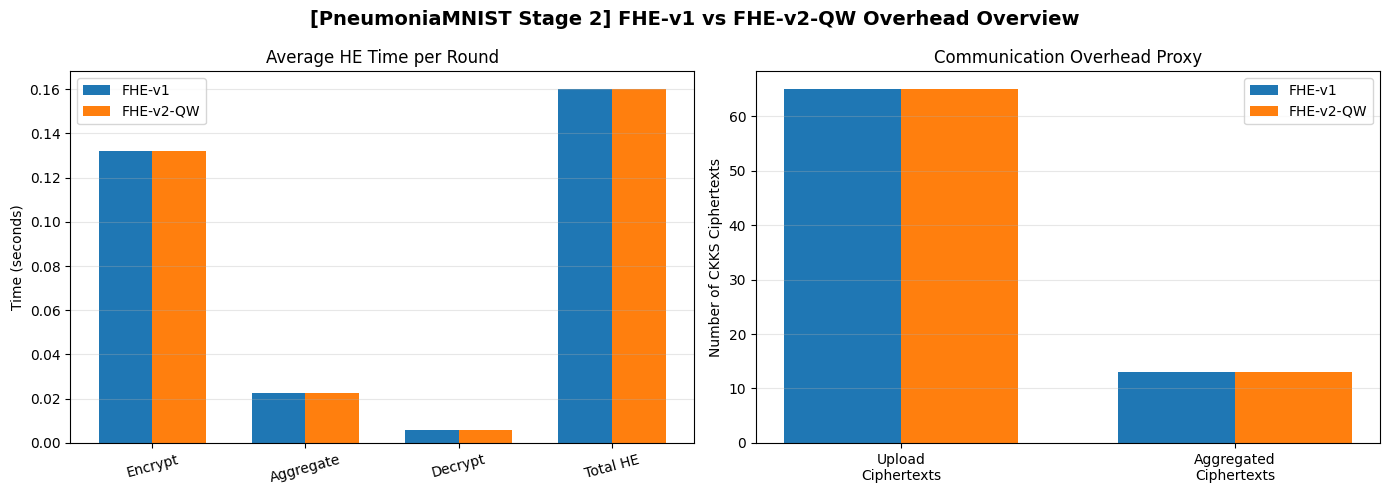

In [58]:
img_fhe_compare_results = {
    "FHE-v1": result_img_stage2_fhe_v1,
    "FHE-v2-QW": result_img_stage2_fhe_v2_qw,
}

img_fhe_overview_df = build_img_fhe_overview_df(img_fhe_compare_results)

display(img_fhe_overview_df)

img_fhe_overview_df.to_csv(
    "IMG_FHE_V1_VS_V2_QW_OVERHEAD_SUMMARY.csv",
    index=False
)

plot_img_fhe_one_overview(
    img_fhe_overview_df,
    title="[PneumoniaMNIST Stage 2] FHE-v1 vs FHE-v2-QW Overhead Overview",
    save_path="IMG_FHE_V1_VS_V2_QW_OVERHEAD_OVERVIEW.png"
)

In [59]:
# PneumoniaMNIST Stage 2 results dictionary

results_stage2 = {
    "Plain-v1": result_img_stage2_plain,
    "Plain-v2-QW": result_img_stage2_plain_qw,
    "FHE-v1": result_img_stage2_fhe_v1,
    "FHE-v2-QW": result_img_stage2_fhe_v2_qw,
}

print("✅ PneumoniaMNIST Stage 2 results packed:")
print(list(results_stage2.keys()))

✅ PneumoniaMNIST Stage 2 results packed:
['Plain-v1', 'Plain-v2-QW', 'FHE-v1', 'FHE-v2-QW']


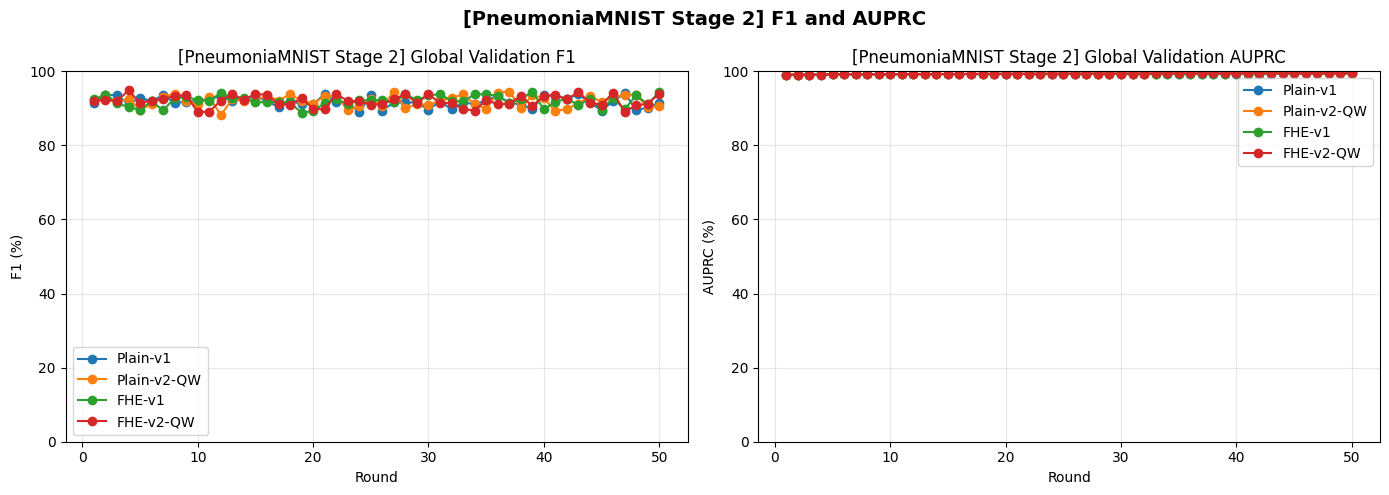

In [60]:
# PneumoniaMNIST Stage 2 - Global Validation F1 and AUPRC

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def _find_metric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_img_stage2_f1_auprc_together(
    results_dict,
    title_prefix="[PneumoniaMNIST Stage 2]"
):
    metric_specs = [
        (["val_f1", "ValF1"], "Global Validation F1", "F1 (%)"),
        (["val_auprc", "ValAUPRC", "val_auprc_percent"], "Global Validation AUPRC", "AUPRC (%)"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{title_prefix} F1 and AUPRC", fontsize=14, fontweight="bold")

    for ax, (candidates, subtitle, ylabel) in zip(axes, metric_specs):
        plotted = False

        for name, result in results_dict.items():
            df = pd.DataFrame(result["history"])

            if "round" in df.columns:
                x = df["round"].values
            else:
                x = np.arange(1, len(df) + 1)

            metric_col = _find_metric_col(df, candidates)

            if metric_col is None:
                print(f"⚠️ {name}: metric not found from {candidates}")
                continue

            ax.plot(
                x,
                df[metric_col].values,
                marker="o",
                label=name
            )
            plotted = True

        ax.set_title(f"{title_prefix} {subtitle}")
        ax.set_xlabel("Round")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 100)
        ax.grid(alpha=0.3)

        if plotted:
            ax.legend()
        else:
            ax.text(
                0.5, 0.5,
                "Metric not found",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

    plt.tight_layout()
    plt.show()


plot_img_stage2_f1_auprc_together(
    results_stage2,
    title_prefix="[PneumoniaMNIST Stage 2]"
)

In [98]:
# FHE-DP-FedAvg and FHE-FedProx helpers
# For CDC + PneumoniaMNIST notebooks

import copy
import numpy as np
import torch
import torch.nn.functional as F


def backbone_delta_l2_norm(delta_sd):
    total = 0.0
    for v in delta_sd.values():
        total += torch.sum(v.detach().float().cpu() ** 2).item()
    return float(np.sqrt(total))


def clip_backbone_delta(delta_sd, max_norm=1.0):
    raw_norm = backbone_delta_l2_norm(delta_sd)
    clip_coef = min(1.0, max_norm / (raw_norm + 1e-12))

    clipped = {}
    for k, v in delta_sd.items():
        clipped[k] = v.detach().cpu() * clip_coef

    return clipped, raw_norm, clip_coef


def add_gaussian_noise_to_delta(avg_delta, noise_std):
    if noise_std is None or noise_std <= 0:
        return avg_delta

    noisy_delta = {}

    for k, v in avg_delta.items():
        noise = torch.normal(
            mean=0.0,
            std=float(noise_std),
            size=v.shape
        )
        noisy_delta[k] = v.detach().cpu() + noise

    return noisy_delta


def local_stage2_train_fedprox(
    model,
    train_loader,
    val_loader,
    global_backbone_sd,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    fedprox_mu=0.01,
    grad_clip=10.0,
):
    model.to(device)
    model.train()

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    # global backbone reference
    global_ref = {
        k: v.detach().to(device)
        for k, v in global_backbone_sd.items()
    }

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    losses = []

    for _ in range(local_epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            ce_loss = F.cross_entropy(logits, yb, weight=ce_weight)

            prox_loss = 0.0
            for name, param in model.backbone.named_parameters():
                if name in global_ref:
                    prox_loss = prox_loss + torch.sum(
                        (param - global_ref[name]) ** 2
                    )

            loss = ce_loss + 0.5 * fedprox_mu * prox_loss
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=grad_clip
                )

            optimizer.step()
            losses.append(loss.item())

    train_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan

    val_metrics = eval_model_binary(
        model=model,
        loader=val_loader,
        device=device,
        threshold=0.5
    )

    return {
        "train_loss": train_loss,
        "val_metrics": val_metrics,
    }

print("✅ DP/FedProx helper functions ready.")

✅ DP/FedProx helper functions ready.


In [99]:
# Unified FHE baselines:
# 1) FHE-DP-FedAvg
# 2) FHE-FedProx
# For CDC + PneumoniaMNIST notebooks

def stage2_train_fhe_baseline(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    he_backend,
    num_rounds=30,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
    method="dp_fedavg",          # "dp_fedavg" or "fedprox"
    dp_clip_norm=1.0,
    dp_noise_multiplier=0.05,
    fedprox_mu=0.01,
    run_name="FHE-BASELINE",
):
    assert method in ["dp_fedavg", "fedprox"]

    print("=" * 80)
    print(f"[{run_name}] Stage 2 FHE baseline training start | method={method}")
    print("=" * 80)

    num_clients = len(client_loaders)

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=num_clients,
        num_classes=num_classes,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    history = []

    best_score = -np.inf
    best_round = None
    best_global_sd = None
    best_client_sds = None

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_train_losses = []
        local_val_metrics = []
        client_sample_sizes = []

        raw_delta_norms = []
        clip_coefs = []

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

            if method == "fedprox":
                out = local_stage2_train_fedprox(
                    model=client_models[cid],
                    train_loader=client_loaders[cid],
                    val_loader=client_val_loaders[cid],
                    global_backbone_sd=global_backbone,
                    local_epochs=local_epochs,
                    lr=lr,
                    device=device,
                    class_weights=class_weights,
                    fedprox_mu=fedprox_mu,
                    grad_clip=10.0,
                )
            else:
                out = local_stage2_train(
                    model=client_models[cid],
                    train_loader=client_loaders[cid],
                    val_loader=client_val_loaders[cid],
                    local_epochs=local_epochs,
                    lr=lr,
                    device=device,
                    class_weights=class_weights,
                    grad_clip=10.0,
                )

            local_train_losses.append(out["train_loss"])
            local_val_metrics.append(out["val_metrics"])
            client_sample_sizes.append(len(client_loaders[cid].dataset))

            local_backbone = get_backbone_state(client_models[cid])
            delta = compute_backbone_delta(local_backbone, global_backbone)

            if method == "dp_fedavg":
                delta, raw_norm, clip_coef = clip_backbone_delta(
                    delta,
                    max_norm=dp_clip_norm
                )
                raw_delta_norms.append(raw_norm)
                clip_coefs.append(clip_coef)

            local_deltas.append(delta)

        # FedAvg baseline: uniform aggregation
        weights = np.ones(num_clients, dtype=np.float64) / num_clients

        # FHE encrypted aggregation
        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,
            device=device
        )

        # DP noise is added to the aggregated clipped update
        # Approximate update-level DP baseline, not a formal accountant.
        if method == "dp_fedavg":
            dp_noise_std = float(dp_noise_multiplier * dp_clip_norm / num_clients)
            avg_delta = add_gaussian_noise_to_delta(
                avg_delta,
                noise_std=dp_noise_std
            )
        else:
            dp_noise_std = 0.0

        global_backbone = apply_backbone_delta(
            global_backbone_sd=global_backbone,
            avg_delta=avg_delta
        )

        load_backbone_state(global_model, global_backbone, device)

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

        global_val_metrics = eval_model_binary(
            model=global_model,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_stage2_personal_models(
            client_models=client_models,
            client_val_loaders=client_val_loaders,
            device=device
        )

        mean_local_train_loss = float(np.nanmean(local_train_losses))

        row = {
            "round": rnd,
            "train_loss": mean_local_train_loss,

            "val_loss": global_val_metrics["loss"],
            "val_acc": global_val_metrics["acc"],
            "val_bal_acc": global_val_metrics["bal_acc"],
            "val_f1": global_val_metrics["f1"],
            "val_recall": global_val_metrics["recall"],
            "val_auprc": global_val_metrics["auprc"],

            "personal_loss": personal_metrics["loss"],
            "personal_acc": personal_metrics["acc"],
            "personal_bal_acc": personal_metrics["bal_acc"],
            "personal_f1": personal_metrics["f1"],
            "personal_recall": personal_metrics["recall"],
            "personal_auprc": personal_metrics["auprc"],

            "method": method,

            "dp_clip_norm": float(dp_clip_norm) if method == "dp_fedavg" else None,
            "dp_noise_multiplier": float(dp_noise_multiplier) if method == "dp_fedavg" else None,
            "dp_noise_std": float(dp_noise_std) if method == "dp_fedavg" else None,
            "delta_norm_mean_preclip": float(np.mean(raw_delta_norms)) if raw_delta_norms else None,
            "clip_hit_rate": float(np.mean(np.array(clip_coefs) < 1.0)) if clip_coefs else None,

            "fedprox_mu": float(fedprox_mu) if method == "fedprox" else None,

            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],

            "weights": weights.tolist(),
        }

        # Some notebooks have these fields, some do not
        if "upload_ciphertexts_per_round" in he_stats:
            row["he_upload_ciphertexts_per_round"] = he_stats["upload_ciphertexts_per_round"]
        if "aggregated_ciphertexts_per_round" in he_stats:
            row["he_aggregated_ciphertexts_per_round"] = he_stats["aggregated_ciphertexts_per_round"]

        history.append(row)

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"TrainLoss={mean_local_train_loss:.4f} | "
            f"ValAcc={global_val_metrics['acc']:.2f}% | "
            f"ValBalAcc={global_val_metrics['bal_acc']:.2f}% | "
            f"ValF1={global_val_metrics['f1']:.2f}% | "
            f"ValAUPRC={global_val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"HE(enc={he_stats['encrypt_time_sec']:.4f}s, "
            f"agg={he_stats['aggregate_time_sec']:.4f}s, "
            f"dec={he_stats['decrypt_time_sec']:.4f}s)"
        )

        score = (
            0.45 * global_val_metrics["bal_acc"]
            + 0.25 * global_val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if score > best_score:
            best_score = score
            best_round = rnd

            best_global_sd = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

            best_client_sds = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in client_models[cid].state_dict().items()
                }
                for cid in range(num_clients)
            ]

    if best_global_sd is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in best_global_sd.items()
        })

    if best_client_sds is not None:
        for cid in range(num_clients):
            client_models[cid].load_state_dict({
                k: v.to(device)
                for k, v in best_client_sds[cid].items()
            })

    final_test_metrics = eval_model_binary(
        model=global_model,
        loader=global_test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 2 FHE baseline completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final global test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "global_model": global_model,
        "client_models": client_models,
        "history": history,
        "best_round": best_round,
        "best_score": best_score,
        "best_global_sd": best_global_sd,
        "best_client_sds": best_client_sds,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
        "method": method,
        "he_config": {
            "poly_modulus_degree": he_backend.poly_modulus_degree,
            "coeff_mod_bit_sizes": he_backend.coeff_mod_bit_sizes,
            "global_scale": he_backend.global_scale,
            "chunk_size": he_backend.chunk_size,
        }
    }

    return result

print("✅ stage2_train_fhe_baseline ready.")

✅ stage2_train_fhe_baseline ready.


In [100]:
# PneumoniaMNIST FHE-DP-FedAvg
result_img_stage2_fhe_dp_fedavg = stage2_train_fhe_baseline(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_img_align_filtered,
    he_backend=he_backend,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=NUM_CLASSES,
    method="dp_fedavg",
    dp_clip_norm=1.0,
    dp_noise_multiplier=0.05,
    run_name="IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG",
)

torch.save(
    result_img_stage2_fhe_dp_fedavg,
    "IMG_PNEUMONIA_STAGE2_FHE_DP_FEDAVG.pt"
)


# PneumoniaMNIST FHE-FedProx
result_img_stage2_fhe_fedprox = stage2_train_fhe_baseline(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_img_align_filtered,
    he_backend=he_backend,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=NUM_CLASSES,
    method="fedprox",
    fedprox_mu=0.01,
    run_name="IMG-PNEUMONIA-STAGE2-FHE-FEDPROX",
)

torch.save(
    result_img_stage2_fhe_fedprox,
    "IMG_PNEUMONIA_STAGE2_FHE_FEDPROX.pt"
)

[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG] Stage 2 FHE baseline training start | method=dp_fedavg

[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG] Round 1/50
HE(numel=25816, chunks=13, enc=0.238519s, agg=0.040452s, dec=0.010333s)
[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG][Round 1/50] TrainLoss=0.2842 | ValAcc=89.50% | ValBalAcc=91.00% | ValF1=92.56% | ValAUPRC=99.10% | PersonalAcc=89.16% | PersonalBalAcc=90.35% | HE(enc=0.2385s, agg=0.0405s, dec=0.0103s)

[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG] Round 2/50
HE(numel=25816, chunks=13, enc=0.227548s, agg=0.039083s, dec=0.010845s)
[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG][Round 2/50] TrainLoss=0.2612 | ValAcc=91.22% | ValBalAcc=91.19% | ValF1=93.92% | ValAUPRC=99.08% | PersonalAcc=91.20% | PersonalBalAcc=90.58% | HE(enc=0.2275s, agg=0.0391s, dec=0.0108s)

[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG] Round 3/50
HE(numel=25816, chunks=13, enc=0.229274s, agg=0.038962s, dec=0.010136s)
[IMG-PNEUMONIA-STAGE2-FHE-DP-FEDAVG][Round 3/50] TrainLoss=0.2618 | ValAcc=88.36% | ValBalAcc=90.47

In [23]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


def load_pt(path):
    print(f"Loading: {path}")
    obj = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    if isinstance(obj, dict) and "history" in obj:
        hist = obj["history"]
        print(f"✅ Loaded | history length={len(hist)} | last round={hist[-1].get('round', None)}")
    else:
        print("✅ Loaded")

    return obj


def pick_existing_path(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"No existing file found from: {paths}")


# ============================================================
# PneumoniaMNIST / IMG Stage 2: load all six results
# ============================================================

img_plain_v1_path = pick_existing_path([
    "./IMG_PNEUMONIA_STAGE2_PLAIN_V1.pt",
])

img_plain_v2_qw_path = pick_existing_path([
    "./IMG_PNEUMONIA_STAGE2_PLAIN_V2_QW.pt",
])

img_fhe_v1_path = pick_existing_path([
    "./IMG_PNEUMONIA_STAGE2_FHE_V1_WITH_TIME.pt",
    "./IMG_PNEUMONIA_STAGE2_FHE_V1.pt",
])

img_fhe_v2_qw_path = pick_existing_path([
    "./IMG_PNEUMONIA_STAGE2_FHE_V2_QW_WITH_TIME.pt",
    "./IMG_PNEUMONIA_STAGE2_FHE_V2_QW.pt",
])

img_fhe_dp_fedavg_path = pick_existing_path([
    "./IMG_PNEUMONIA_STAGE2_FHE_DP_FEDAVG.pt",
])

img_fhe_fedprox_path = pick_existing_path([
    "./IMG_PNEUMONIA_STAGE2_FHE_FEDPROX.pt",
])


result_img_stage2_plain_v1 = load_pt(img_plain_v1_path)
result_img_stage2_plain_v2_qw = load_pt(img_plain_v2_qw_path)

result_img_stage2_fhe_v1 = load_pt(img_fhe_v1_path)
result_img_stage2_fhe_v2_qw = load_pt(img_fhe_v2_qw_path)

result_img_stage2_fhe_dp_fedavg = load_pt(img_fhe_dp_fedavg_path)
result_img_stage2_fhe_fedprox = load_pt(img_fhe_fedprox_path)


# ============================================================
# Create old-compatible aliases
# 防止旧代码里还在用这些名字
# ============================================================

stage2_plain_result = result_img_stage2_plain_v1
stage2_plain_v2_qw_result = result_img_stage2_plain_v2_qw

stage2_fhe_v1_result = result_img_stage2_fhe_v1
stage2_fhe_v2_qw_result = result_img_stage2_fhe_v2_qw

stage2_fhe_dp_fedavg_result = result_img_stage2_fhe_dp_fedavg
stage2_fhe_fedprox_result = result_img_stage2_fhe_fedprox


result_stage2_plain_v1 = result_img_stage2_plain_v1
result_stage2_plain_v2_qw = result_img_stage2_plain_v2_qw

result_stage2_fhe_v1 = result_img_stage2_fhe_v1
result_stage2_fhe_v2_qw = result_img_stage2_fhe_v2_qw

result_stage2_fhe_dp_fedavg = result_img_stage2_fhe_dp_fedavg
result_stage2_fhe_fedprox = result_img_stage2_fhe_fedprox


print("\n✅ IMG / PneumoniaMNIST Stage 2 variables loaded and aliases created.")

Loading: ./IMG_PNEUMONIA_STAGE2_PLAIN_V1.pt
✅ Loaded | history length=50 | last round=50
Loading: ./IMG_PNEUMONIA_STAGE2_PLAIN_V2_QW.pt
✅ Loaded | history length=50 | last round=50
Loading: ./IMG_PNEUMONIA_STAGE2_FHE_V1_WITH_TIME.pt
✅ Loaded | history length=50 | last round=50
Loading: ./IMG_PNEUMONIA_STAGE2_FHE_V2_QW_WITH_TIME.pt
✅ Loaded | history length=50 | last round=50
Loading: ./IMG_PNEUMONIA_STAGE2_FHE_DP_FEDAVG.pt
✅ Loaded | history length=50 | last round=50
Loading: ./IMG_PNEUMONIA_STAGE2_FHE_FEDPROX.pt
✅ Loaded | history length=50 | last round=50

✅ IMG / PneumoniaMNIST Stage 2 variables loaded and aliases created.


In [24]:
img_results_to_check = {
    "Plain-v1": result_img_stage2_plain_v1,
    "Plain-v2-QW": result_img_stage2_plain_v2_qw,
    "FHE-FedAvg": result_img_stage2_fhe_v1,
    "FHE-v2-QW": result_img_stage2_fhe_v2_qw,
    "FHE-DP-FedAvg": result_img_stage2_fhe_dp_fedavg,
    "FHE-FedProx": result_img_stage2_fhe_fedprox,
}

for name, result in img_results_to_check.items():
    df = pd.DataFrame(result["history"])
    print(
        name,
        "| history length:", len(df),
        "| min round:", df["round"].min(),
        "| max round:", df["round"].max(),
        "| columns:", list(df.columns)[:10]
    )

Plain-v1 | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
Plain-v2-QW | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
FHE-FedAvg | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
FHE-v2-QW | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
FHE-DP-FedAvg | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'p

In [25]:
results_stage2_img = {
    "Plain-v1": result_img_stage2_plain_v1,
    "Plain-v2-QW": result_img_stage2_plain_v2_qw,
    "FHE-FedAvg": result_img_stage2_fhe_v1,
    "FHE-DP-FedAvg": result_img_stage2_fhe_dp_fedavg,
    "FHE-FedProx": result_img_stage2_fhe_fedprox,
    "FHE-v2-QW": result_img_stage2_fhe_v2_qw,
}

group1_method_map = {
    "Plain-FedAvg": "Plain-v1",
    "Plain-QW": "Plain-v2-QW",
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-QW": "FHE-v2-QW",
}

group2_method_map = {
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-DP-FedAvg": "FHE-DP-FedAvg",
    "FHE-FedProx": "FHE-FedProx",
    "FHE-QW": "FHE-v2-QW",
}


def build_curve_group(results_dict, method_map):
    group = {}

    for display_name, key in method_map.items():
        if key in results_dict:
            group[display_name] = results_dict[key]
        else:
            print(f"⚠️ Missing method: {key}")

    return group


img_group1 = build_curve_group(results_stage2_img, group1_method_map)
img_group2 = build_curve_group(results_stage2_img, group2_method_map)

print("IMG Group 1:", list(img_group1.keys()))
print("IMG Group 2:", list(img_group2.keys()))

IMG Group 1: ['Plain-FedAvg', 'Plain-QW', 'FHE-FedAvg', 'FHE-QW']
IMG Group 2: ['FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx', 'FHE-QW']


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_metric(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_one_stage2_metric(
    results_dict,
    metric_candidates,
    ylabel,
    title,
    ylim=None,
    suffix="",
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        metric_col = _find_metric(df, metric_candidates)

        if metric_col is None:
            print(f"⚠️ {name} not found metric from {metric_candidates}")
            print("Available columns:", list(df.columns))
            continue

        y = df[metric_col].values

        # 不再给 QW 加星号
        label_name = name

        plt.plot(
            x,
            y,
            marker="o",
            label=f"{label_name}{suffix}"
        )

        plotted = True

    if not plotted:
        print("No valid metric found.")
        return

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)

    legend = plt.legend(loc=legend_loc)

    # 只加粗 FHE-QW 的 legend 字体
    for text in legend.get_texts():
        if "FHE-QW" in text.get_text():
            text.set_fontweight("bold")

    plt.grid(alpha=0.3)
    plt.show()

def plot_one_stage2_personalized(
    results_dict,
    title,
    ylim=None,
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        # 不再给 QW 加星号
        label_name = name

        acc_key = _find_metric(df, ["personal_acc", "PersonalAcc"])
        bal_key = _find_metric(df, ["personal_bal_acc", "PersonalBalAcc"])

        if acc_key is not None:
            plt.plot(
                x,
                df[acc_key].values,
                marker="o",
                label=f"{label_name} PersonalAcc"
            )
            plotted = True

        if bal_key is not None:
            plt.plot(
                x,
                df[bal_key].values,
                marker="s",
                linestyle="--",
                label=f"{label_name} PersonalBalAcc"
            )
            plotted = True

    if not plotted:
        print("No valid personalized metrics found.")
        return

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(title)

    legend = plt.legend(loc=legend_loc)

    # 只加粗 FHE-QW 的 legend 字体
    for text in legend.get_texts():
        if "FHE-QW" in text.get_text():
            text.set_fontweight("bold")

    plt.grid(alpha=0.3)
    plt.show()

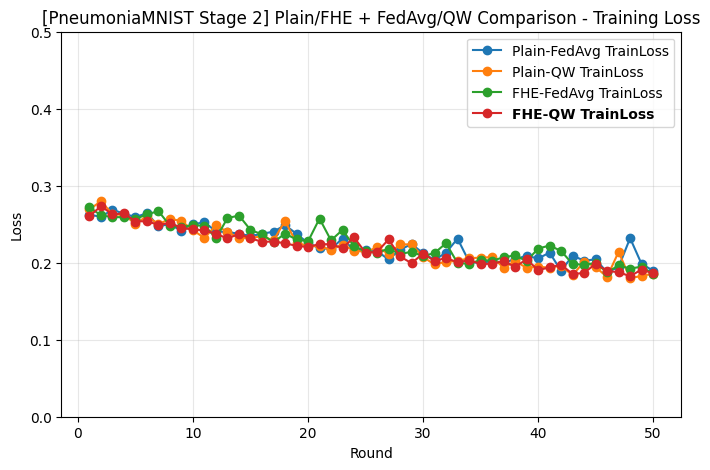

In [42]:
plot_one_stage2_metric(
    results_dict=img_group1,
    metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
    ylabel="Loss",
    title="[PneumoniaMNIST Stage 2] Plain/FHE + FedAvg/QW Comparison - Training Loss",
    ylim=(0, 0.5),
    suffix=" TrainLoss",
    legend_loc="upper right"
)

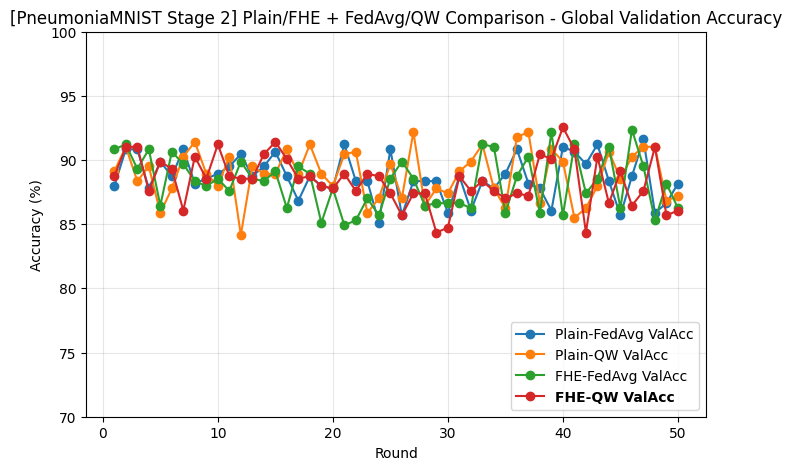

In [41]:
plot_one_stage2_metric(
    results_dict=img_group1,
    metric_candidates=["val_acc", "ValAcc"],
    ylabel="Accuracy (%)",
    title="[PneumoniaMNIST Stage 2] Plain/FHE + FedAvg/QW Comparison - Global Validation Accuracy",
    ylim=(70, 100),
    suffix=" ValAcc",
    legend_loc="lower right"
)

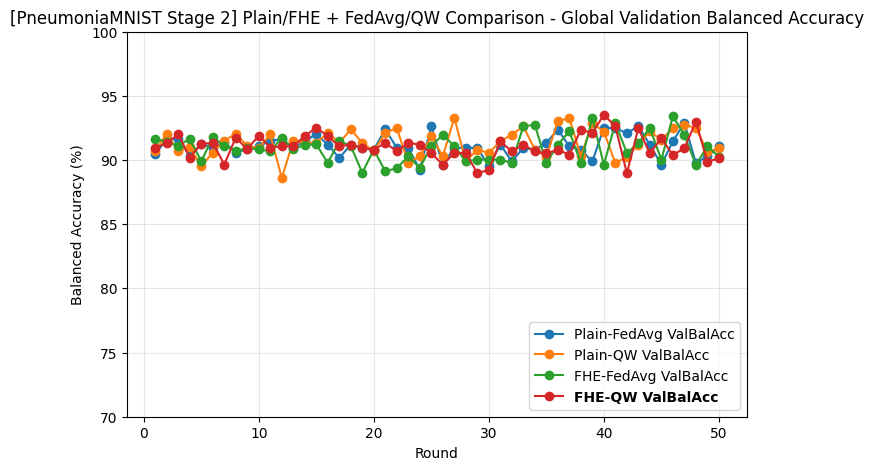

In [40]:
plot_one_stage2_metric(
    results_dict=img_group1,
    metric_candidates=["val_bal_acc", "ValBalAcc"],
    ylabel="Balanced Accuracy (%)",
    title="[PneumoniaMNIST Stage 2] Plain/FHE + FedAvg/QW Comparison - Global Validation Balanced Accuracy",
    ylim=(70, 100),
    suffix=" ValBalAcc",
    legend_loc="lower right"
)

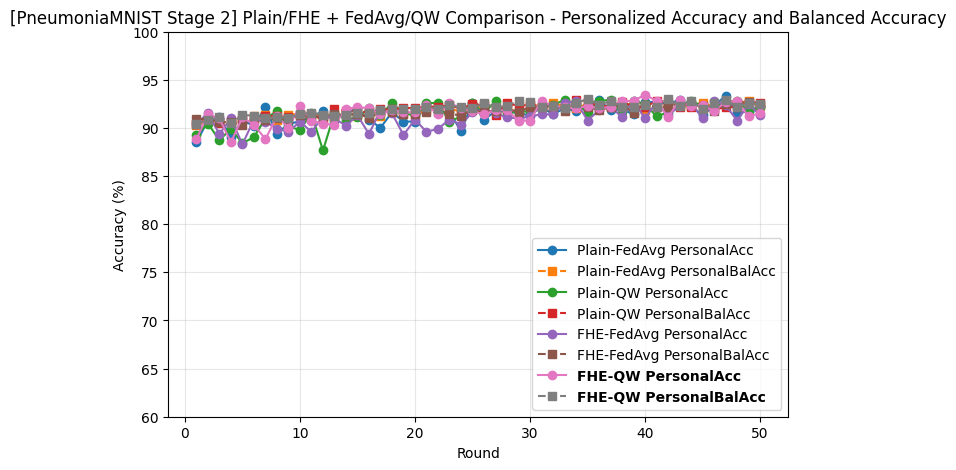

In [50]:
plot_one_stage2_personalized(
    results_dict=img_group1,
    title="[PneumoniaMNIST Stage 2] Plain/FHE + FedAvg/QW Comparison - Personalized Accuracy and Balanced Accuracy",
    ylim=(60, 100),
    legend_loc="lower right"
)

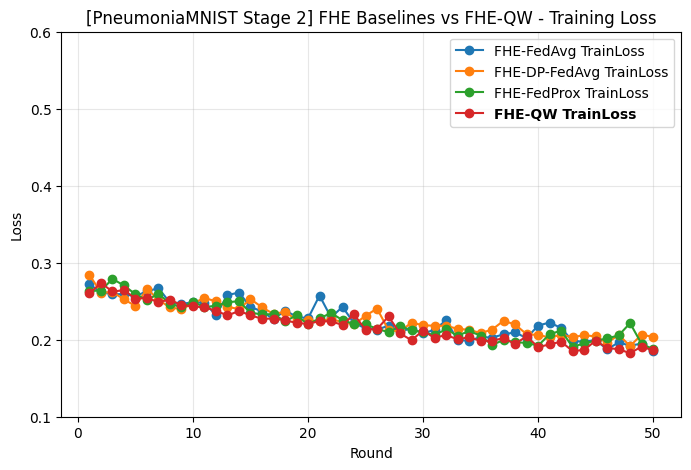

In [38]:
plot_one_stage2_metric(
    results_dict=img_group2,
    metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
    ylabel="Loss",
    title="[PneumoniaMNIST Stage 2] FHE Baselines vs FHE-QW - Training Loss",
    ylim=(0.1, 0.6),
    suffix=" TrainLoss",
    legend_loc="upper right"
)

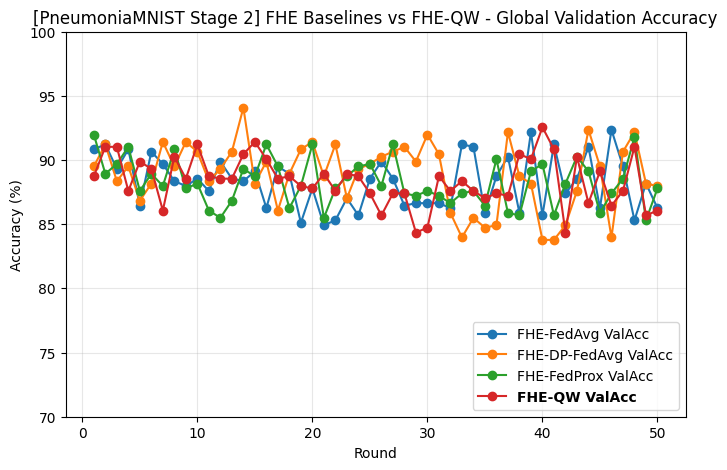

In [37]:
plot_one_stage2_metric(
    results_dict=img_group2,
    metric_candidates=["val_acc", "ValAcc"],
    ylabel="Accuracy (%)",
    title="[PneumoniaMNIST Stage 2] FHE Baselines vs FHE-QW - Global Validation Accuracy",
    ylim=(70, 100),
    suffix=" ValAcc",
    legend_loc="lower right"
)

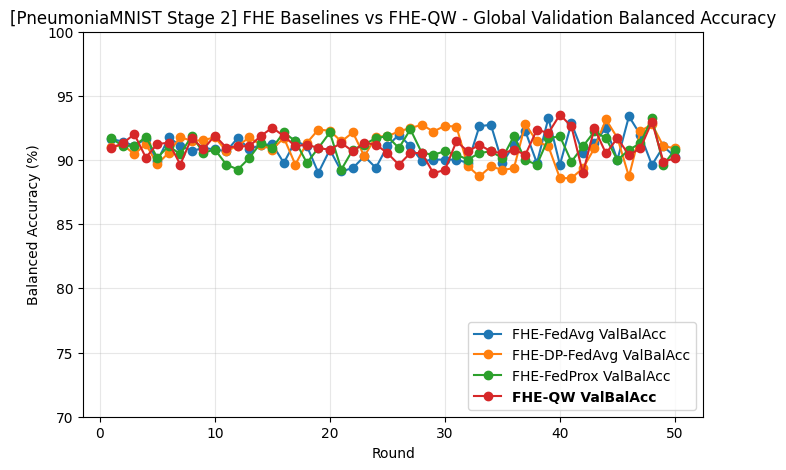

In [36]:
plot_one_stage2_metric(
    results_dict=img_group2,
    metric_candidates=["val_bal_acc", "ValBalAcc"],
    ylabel="Balanced Accuracy (%)",
    title="[PneumoniaMNIST Stage 2] FHE Baselines vs FHE-QW - Global Validation Balanced Accuracy",
    ylim=(70, 100),
    suffix=" ValBalAcc",
    legend_loc="lower right"
)

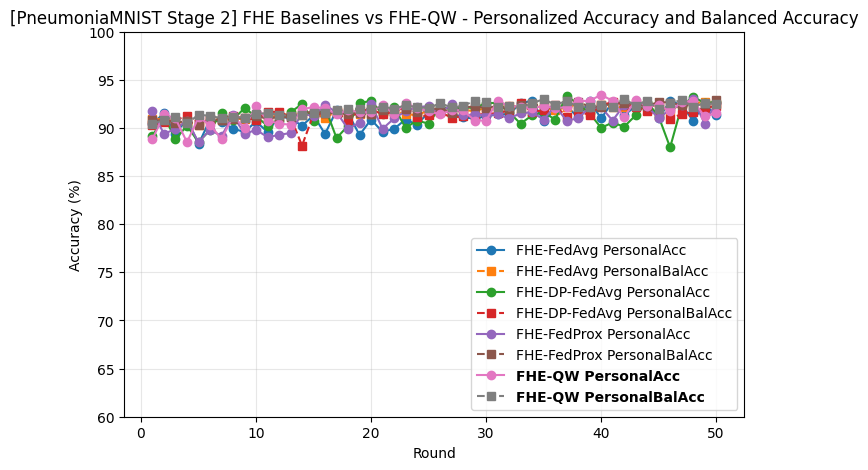

In [51]:
plot_one_stage2_personalized(
    results_dict=img_group2,
    title="[PneumoniaMNIST Stage 2] FHE Baselines vs FHE-QW - Personalized Accuracy and Balanced Accuracy",
    ylim=(60, 100),
    legend_loc="lower right"
)